# 🏥 IUI Prediction - Model Training & XAI (ข้อมูลทั้งหมด)

In [1]:
import sys
print(sys.executable)

import os
if os.getcwd().endswith("src"):
    os.chdir("..")

import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN

import shap

warnings.filterwarnings("ignore")


def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_")
        for col in df.columns
    ]
    return df


def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    return thresholds[np.argmax(j_scores)]


def calculate_net_benefit(y_true, y_prob, threshold):
    if threshold <= 0 or threshold >= 1:
        return np.nan

    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    threshold,
    outdir="reports_ours/figures/confusion_matrices"
):
    os.makedirs(outdir, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Preg (0)", "Preg (1)"],
        yticklabels=["Non-Preg (0)", "Preg (1)"]
    )
    plt.title(f"Confusion Matrix\n{model_name}\n(Threshold: {threshold:.3f})")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_CM.png")
    plt.close()


def plot_roc_curve(
    y_true,
    y_prob,
    model_name,
    auc_score,
    best_threshold,
    outdir="reports_ours/figures/roc_curves"
):
    os.makedirs(outdir, exist_ok=True)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve (area = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
    plt.scatter(
        [best_fpr],
        [best_tpr],
        marker="o",
        s=100,
        label=f"Optimal Threshold ({best_threshold:.2f})",
        zorder=5
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_ROC.png")
    plt.close()


print("✅ SETUP OK")

c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
✅ SETUP OK


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. โหลดและเตรียมข้อมูล (Standard - ข้อมูลทั้งหมด)

In [2]:
# ==========================================
# Block 2: Load data, drop hCG_Type, group split, and impute
# ==========================================

df = pd.read_csv('data/processed/cycle_level_ready_for_ml.csv')
df = clean_column_names(df)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# กัน Date หลุดเข้าโมเดลหลัก
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

# ตัด treatment-artifact variable ออกตั้งแต่ต้น
drop_cols = ['hCG_Type']
df = df.drop(columns=drop_cols, errors='ignore')

# target ต้องมีและเป็น numeric
if 'Result' not in df.columns:
    raise ValueError("Target column 'Result' not found.")

df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])

valid_target = {0, 1, 0.0, 1.0}
bad_target_vals = sorted(set(df['Result'].dropna().unique()) - valid_target)
if bad_target_vals:
    raise ValueError(f"Unexpected values in Result: {bad_target_vals}")

df['Result'] = df['Result'].astype(int)

# object columns อื่นให้พยายามแปลงเป็น numeric
object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())

# ต้องมี HN สำหรับ group split
if 'HN' not in df.columns:
    raise ValueError("Column 'HN' is required for group split.")

df = df.dropna(subset=['HN'])
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

# แยก X / y / groups
X_full = df.drop(columns=['Result'], errors='ignore')
y_full = df['Result'].copy()
groups = df['HN']

# group split by patient ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test = X_full.iloc[test_idx].copy()
y_train = y_full.iloc[train_idx].copy()
y_test = y_full.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

# เก็บข้อมูลอ้างอิงสำหรับ downstream analyses
keep_cols = [c for c in ['HN', 'Cycle_Number'] if c in X_test.columns]
test_info = X_test[keep_cols].copy() if keep_cols else pd.DataFrame(index=X_test.index)

# impute หลัง split เท่านั้น
cols_to_impute = [c for c in X_train.columns if c != 'HN']

all_nan_cols = [c for c in cols_to_impute if X_train[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns in train:", all_nan_cols)

cols_to_impute = [c for c in cols_to_impute if c not in all_nan_cols]

imputer = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer.fit_transform(X_train[cols_to_impute]),
    columns=cols_to_impute,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    imputer.transform(X_test[cols_to_impute]),
    columns=cols_to_impute,
    index=X_test.index
)

# ใส่ HN กลับมาเพื่ออ้างอิงก่อนลบทิ้งจาก feature set
X_train_num['HN'] = X_train['HN'].values
X_test_num['HN'] = X_test['HN'].values

# เช็กว่าไม่มี patient leakage
train_hn = set(X_train_num['HN'])
test_hn = set(X_test_num['HN'])
overlap = train_hn.intersection(test_hn)
print("HN overlap train/test:", len(overlap))
assert len(overlap) == 0, "Patient leakage detected: overlapping HN in train/test"

X_train = X_train_num.copy()
X_test = X_test_num.copy()

# ลบ HN ก่อนเข้าโมเดล
X_train = X_train.drop(columns=['HN'])
X_test = X_test.drop(columns=['HN'])

# sanity check
for bad_col in ['Date', 'HN', 'Result']:
    assert bad_col not in X_train.columns, f'{bad_col} should not be in X_train'
    assert bad_col not in X_test.columns, f'{bad_col} should not be in X_test'

if 'hCG_Type' in X_train.columns or 'hCG_Type' in X_test.columns:
    raise ValueError("hCG_Type should have been removed before training.")

suspicious_cols = [c for c in X_train.columns if 'result' in c.lower() or 'outcome' in c.lower()]
if suspicious_cols:
    raise ValueError(f"Potential leakage columns found: {suspicious_cols}")

print(f'Split done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f'จำนวนคอลัมน์ที่ใช้เทรน: {X_train.shape[1]} คอลัมน์')
print(f'Event rate train: {y_train.mean():.4f}')
print(f'Event rate test: {y_test.mean():.4f}')
print("Train positives:", int(y_train.sum()), "out of", len(y_train))
print("Test positives:", int(y_test.sum()), "out of", len(y_test))
print("Dropped columns at load stage:", drop_cols)

Remaining object columns: ['HN']
HN overlap train/test: 0
Split done. Train: 2348, Test: 597
จำนวนคอลัมน์ที่ใช้เทรน: 53 คอลัมน์
Event rate train: 0.0605
Event rate test: 0.0687
Train positives: 142 out of 2348
Test positives: 41 out of 597
Dropped columns at load stage: ['hCG_Type']


### 3. Hyperparameter Tuning & Model Selection

In [3]:
# ==========================================
# Block 3: Main Model Comparison
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict

results_list = []
trained_models = {}

os.makedirs('models_ours/saved_models', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)

pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv = GroupKFold(n_splits=3)

models_params = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                random_state=42,
                max_iter=2000
            ))
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 20, None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=pos_weight
        ),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 4, 5]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(
            random_state=42,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'iterations': [100, 200, 300],
            'depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        }
    },
    'MLP': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                random_state=42,
                max_iter=1000
            ))
        ]),
        'params': {
            'model__hidden_layer_sizes': [(50,), (100, 50)],
            'model__alpha': [0.0001, 0.001]
        }
    }
}

for m_name, mp in models_params.items():
    print(f'Training {m_name}...')

    rs = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=6,
        cv=group_cv,
        scoring='average_precision',
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    rs.fit(X_train, y_train, groups=groups_train)
    best_m = rs.best_estimator_

    # -----------------------------
    # choose threshold on TRAIN only
    # using out-of-fold CV predictions
    # -----------------------------
    oof_prob = cross_val_predict(
        best_m,
        X_train,
        y_train,
        groups=groups_train,
        cv=group_cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    th = find_optimal_threshold(y_train, oof_prob)

    # -----------------------------
    # final evaluation on held-out TEST
    # -----------------------------
    y_prob = best_m.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    y_pred_opt = (y_prob >= th).astype(int)

    acc = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, zero_division=0)
    rec = recall_score(y_test, y_pred_opt, zero_division=0)
    f1 = f1_score(y_test, y_pred_opt, zero_division=0)

    print(
        f"{m_name}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
        f"Brier={brier:.4f}, Acc={acc:.4f}, F1={f1:.4f}, Th(train-CV)={th:.4f}"
    )

    results_list.append({
        'Model': m_name,
        'Best_Params': str(rs.best_params_),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier': brier,
        'Optimal_Th_from_TrainCV': th
    })

    trained_models[m_name] = {
        'model': best_m,
        'probs': y_prob,
        'best_params': rs.best_params_,
        'threshold': th,
        'train_oof_probs': oof_prob
    }

    os.makedirs(f'models_ours/saved_models/{m_name}', exist_ok=True)
    joblib.dump(best_m, f'models_ours/saved_models/{m_name}/{m_name}.joblib')

results_df = pd.DataFrame(results_list).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df.to_excel(
    'reports_ours/tables/model_performance_comparison_main.xlsx',
    index=False
)

print('\n✅ Main model comparison complete')
print(results_df.head(10))

Training LogisticRegression...
LogisticRegression: PR-AUC=0.1128, ROC-AUC=0.6974, Brier=0.2135, Acc=0.4221, F1=0.1727, Th(train-CV)=0.3579
Training RandomForest...
RandomForest: PR-AUC=0.0909, ROC-AUC=0.6236, Brier=0.0646, Acc=0.4791, F1=0.1707, Th(train-CV)=0.0562
Training XGBoost...
XGBoost: PR-AUC=0.0944, ROC-AUC=0.6377, Brier=0.2014, Acc=0.4858, F1=0.1769, Th(train-CV)=0.4265
Training CatBoost...
CatBoost: PR-AUC=0.0971, ROC-AUC=0.6370, Brier=0.1922, Acc=0.4925, F1=0.1744, Th(train-CV)=0.3937
Training MLP...
MLP: PR-AUC=0.0791, ROC-AUC=0.5358, Brier=0.0813, Acc=0.6147, F1=0.0873, Th(train-CV)=0.0005

✅ Main model comparison complete
                Model                                        Best_Params  \
0  LogisticRegression                                  {'model__C': 0.1}   
1            CatBoost  {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'ite...   
2             XGBoost  {'n_estimators': 100, 'max_depth': 2, 'learnin...   
3        RandomForest             {'n_estimators': 

In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GroupKFold

In [5]:
# ==========================================
# Sensitivity Analysis: Imbalance Handling
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

imbalance_results = []
imbalance_models = {}

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('models_ours/imbalance_sensitivity', exist_ok=True)

group_cv = GroupKFold(n_splits=3)
pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))

samplers_sens = {
    'Baseline_NoResampling': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

for s_name, sampler in samplers_sens.items():
    print(f"\n===== Sampler: {s_name} =====")

    for m_name in ['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost', 'MLP']:
        print(f"Training {m_name} with {s_name}...")

        if m_name == 'LogisticRegression':
            if sampler is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler),
                    ('model', LogisticRegression(
                        class_weight=None,
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            params = {'model__C': [0.01, 0.1, 1, 10]}

        elif m_name == 'RandomForest':
            if sampler is None:
                estimator = ImbPipeline([
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight='balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler),
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight=None
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200],
                'model__max_depth': [5, 10, None]
            }

        elif m_name == 'XGBoost':
            if sampler is None:
                estimator = ImbPipeline([
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=pos_weight
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler),
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=1.0
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [2, 3, 4]
            }

        elif m_name == 'CatBoost':
            if sampler is None:
                estimator = ImbPipeline([
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0,
                        auto_class_weights='Balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler),
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0
                    ))
                ])
            params = {
                'model__iterations': [100, 200, 300],
                'model__depth': [3, 4, 5, 6],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__l2_leaf_reg': [1, 3, 5]
            }

        elif m_name == 'MLP':
            if sampler is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            params = {
                'model__hidden_layer_sizes': [(50,), (100, 50)],
                'model__alpha': [0.0001, 0.001]
            }

        rs = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=6,
            cv=group_cv,
            scoring='average_precision',
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        rs.fit(X_train, y_train, groups=groups_train)
        best_m = rs.best_estimator_

        # choose threshold on TRAIN only using group-aware OOF predictions
        oof_prob = cross_val_predict(
            best_m,
            X_train,
            y_train,
            groups=groups_train,
            cv=group_cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        th = find_optimal_threshold(y_train, oof_prob)

        # evaluate on held-out TEST
        y_prob = best_m.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        brier = brier_score_loss(y_test, y_prob)

        y_pred_opt = (y_prob >= th).astype(int)

        acc = accuracy_score(y_test, y_pred_opt)
        prec = precision_score(y_test, y_pred_opt, zero_division=0)
        rec = recall_score(y_test, y_pred_opt, zero_division=0)
        f1 = f1_score(y_test, y_pred_opt, zero_division=0)

        print(
            f"{m_name} + {s_name}: PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
            f"Brier={brier:.4f}, Acc={acc:.4f}, F1={f1:.4f}, Th(train-CV)={th:.4f}"
        )

        imbalance_results.append({
            'Imbalance_Method': s_name,
            'Model': m_name,
            'Best_Params': str(rs.best_params_),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Brier': brier,
            'Optimal_Th_from_TrainCV': th
        })

        key = f"{m_name}__{s_name}"
        imbalance_models[key] = {
            'model': best_m,
            'probs': y_prob,
            'best_params': rs.best_params_,
            'threshold': th,
            'train_oof_probs': oof_prob
        }

        model_dir = f"models_ours/imbalance_sensitivity/{m_name}"
        os.makedirs(model_dir, exist_ok=True)
        joblib.dump(best_m, f"{model_dir}/{m_name}_{s_name}.joblib")

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

imbalance_results_df.to_excel(
    'reports_ours/tables/imbalance_sensitivity_comparison.xlsx',
    index=False
)

print("\n✅ Imbalance sensitivity analysis complete")
print(imbalance_results_df.head(15))


===== Sampler: Baseline_NoResampling =====
Training LogisticRegression with Baseline_NoResampling...
LogisticRegression + Baseline_NoResampling: PR-AUC=0.1128, ROC-AUC=0.6974, Brier=0.2135, Acc=0.4221, F1=0.1727, Th(train-CV)=0.3579
Training RandomForest with Baseline_NoResampling...
RandomForest + Baseline_NoResampling: PR-AUC=0.0873, ROC-AUC=0.5878, Brier=0.0645, Acc=0.4958, F1=0.1473, Th(train-CV)=0.0550
Training XGBoost with Baseline_NoResampling...
XGBoost + Baseline_NoResampling: PR-AUC=0.1117, ROC-AUC=0.6579, Brier=0.2019, Acc=0.4255, F1=0.1695, Th(train-CV)=0.4000
Training CatBoost with Baseline_NoResampling...
CatBoost + Baseline_NoResampling: PR-AUC=0.0971, ROC-AUC=0.6370, Brier=0.1922, Acc=0.4925, F1=0.1744, Th(train-CV)=0.3937
Training MLP with Baseline_NoResampling...
MLP + Baseline_NoResampling: PR-AUC=0.0791, ROC-AUC=0.5358, Brier=0.0813, Acc=0.6147, F1=0.0873, Th(train-CV)=0.0005

===== Sampler: SMOTE =====
Training LogisticRegression with SMOTE...
LogisticRegression +

In [9]:
# ==========================================
# Show Metrics of Best Model (by PR-AUC)
# ==========================================

# เรียงตาม PR-AUC
best_row = imbalance_results_df.sort_values(
    "PR-AUC",
    ascending=False
).iloc[0]

model_name = best_row["Model"]
method_name = best_row["Imbalance_Method"]
threshold = best_row["Optimal_Th_from_TrainCV"]

model_key = f"{model_name}__{method_name}"

print("===== BEST MODEL =====")
print(f"Model: {model_name}")
print(f"Imbalance method: {method_name}")
print()

print("===== PERFORMANCE METRICS =====")
print(f"PR-AUC : {best_row['PR-AUC']:.4f}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f"Brier  : {best_row['Brier']:.4f}")
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"F1-score : {best_row['F1']:.4f}")
print()

# =========================
# Predictions
# =========================

y_prob = imbalance_models[model_key]["probs"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("===== CONFUSION MATRIX =====")
print(cm)
print()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)
print()

print("===== CLINICAL METRICS =====")

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
npv = tn/(tn+fn)

print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity        : {specificity:.3f}")
print(f"Precision (PPV)    : {precision:.3f}")
print(f"NPV                : {npv:.3f}")
print()

print(f"Threshold used: {threshold:.4f}")

===== BEST MODEL =====
Model: CatBoost
Imbalance method: BorderlineSMOTE

===== PERFORMANCE METRICS =====
PR-AUC : 0.1205
ROC-AUC: 0.7163
Brier  : 0.0694
Accuracy : 0.4221
F1-score : 0.1844

===== CONFUSION MATRIX =====
[[213 343]
 [  2  39]]

TN = 213
FP = 343
FN = 2
TP = 39

===== CLINICAL METRICS =====
Sensitivity (Recall): 0.951
Specificity        : 0.383
Precision (PPV)    : 0.102
NPV                : 0.991

Threshold used: 0.0994


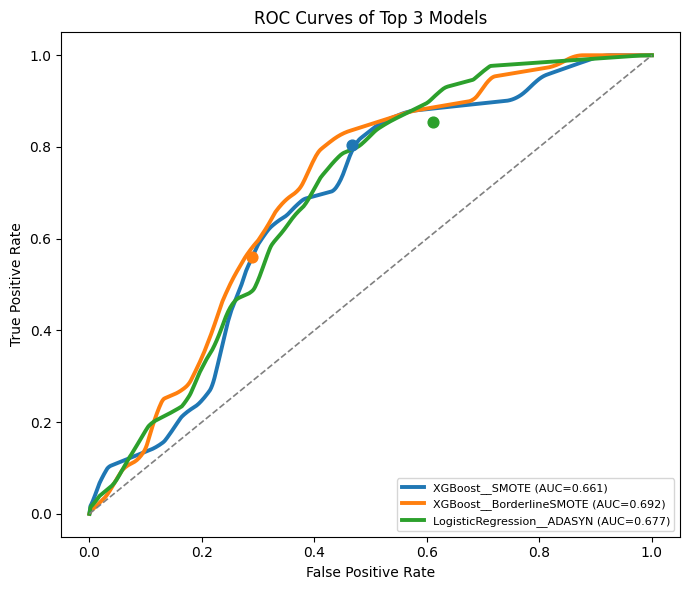

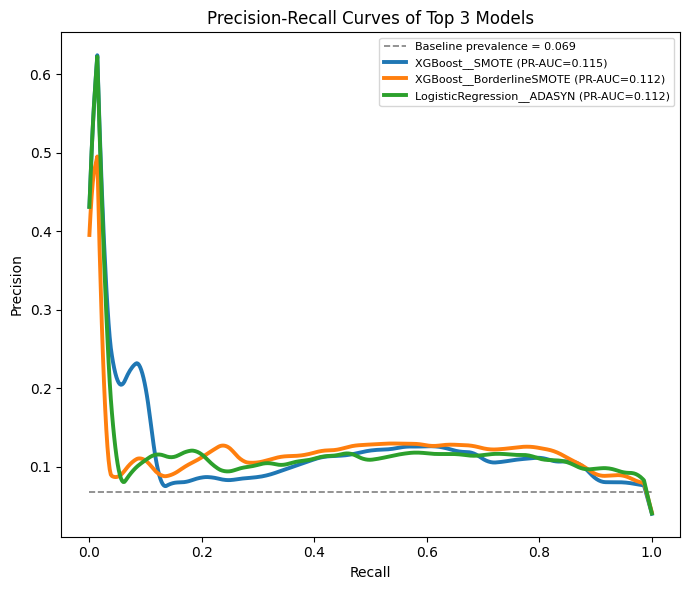


Summary of plotted models:
1. XGBoost + SMOTE | PR-AUC=0.1155, ROC-AUC=0.6612, Brier=0.0657, Threshold=0.0752
2. XGBoost + BorderlineSMOTE | PR-AUC=0.1123, ROC-AUC=0.6923, Brier=0.0670, Threshold=0.1235
3. LogisticRegression + ADASYN | PR-AUC=0.1122, ROC-AUC=0.6768, Brier=0.2120, Threshold=0.3085


In [80]:
# ==========================================
# Paper-ready ROC Curves (Top 3, smoothed for visualization only)
# ==========================================

from sklearn.metrics import roc_curve
import numpy as np
import matplotlib.pyplot as plt
import os

top_n = 3
top_models_df = imbalance_results_df.head(top_n).copy()

os.makedirs("reports_ours/figures/roc_curves", exist_ok=True)

plt.figure(figsize=(7, 6))

for _, row in top_models_df.iterrows():
    model_name = row["Model"]
    method_name = row["Imbalance_Method"]
    roc_auc = row["ROC-AUC"]
    threshold = row["Optimal_Th_from_TrainCV"]

    model_key = f"{model_name}__{method_name}"
    y_prob = imbalance_models[model_key]["probs"]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # operating point from train-CV-derived threshold
    best_idx = np.argmin(np.abs(thresholds - threshold))
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]

    # collapse duplicate FPRs
    uniq_fpr = np.unique(fpr)
    uniq_tpr = np.array([tpr[fpr == x].max() for x in uniq_fpr])

    # dense interpolation
    x_smooth = np.linspace(0, 1, 500)
    y_smooth = np.interp(x_smooth, uniq_fpr, uniq_tpr)

    # light smoothing
    window = 15
    kernel = np.ones(window) / window
    y_smooth = np.convolve(y_smooth, kernel, mode="same")

    # enforce ROC-like shape
    y_smooth = np.clip(y_smooth, 0, 1)
    y_smooth = np.maximum.accumulate(y_smooth)
    y_smooth[0] = 0.0
    y_smooth[-1] = 1.0

    plt.plot(
        x_smooth,
        y_smooth,
        lw=2.8,
        label=f"{model_key} (AUC={roc_auc:.3f})"
    )
    plt.scatter(best_fpr, best_tpr, s=60, zorder=5)

plt.plot([0, 1], [0, 1], linestyle="--", lw=1.2, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves of Top {top_n} Models")
plt.legend(loc="lower right", fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig(
    f"reports_ours/figures/roc_curves/top_{top_n}_models_smoothed_roc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ==========================================
# Paper-ready PR Curves (Top 3, smoothed for visualization only)
# ==========================================

from sklearn.metrics import precision_recall_curve

os.makedirs("reports_ours/figures/pr_curves", exist_ok=True)

plt.figure(figsize=(7, 6))

baseline_prevalence = y_test.mean()
plt.hlines(
    baseline_prevalence,
    0,
    1,
    linestyles="--",
    lw=1.2,
    color="gray",
    label=f"Baseline prevalence = {baseline_prevalence:.3f}"
)

for _, row in top_models_df.iterrows():
    model_name = row["Model"]
    method_name = row["Imbalance_Method"]
    pr_auc = row["PR-AUC"]

    model_key = f"{model_name}__{method_name}"
    y_prob = imbalance_models[model_key]["probs"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    # sort by recall before interpolation
    order = np.argsort(recall)
    recall_sorted = recall[order]
    precision_sorted = precision[order]

    # collapse duplicate recall values
    uniq_recall = np.unique(recall_sorted)
    uniq_precision = np.array([precision_sorted[recall_sorted == x].max() for x in uniq_recall])

    # dense interpolation
    x_smooth = np.linspace(0, 1, 500)
    y_smooth = np.interp(x_smooth, uniq_recall, uniq_precision)

    # light smoothing
    window = 15
    kernel = np.ones(window) / window
    y_smooth = np.convolve(y_smooth, kernel, mode="same")

    # bounds
    y_smooth = np.clip(y_smooth, 0, 1)

    plt.plot(
        x_smooth,
        y_smooth,
        lw=2.8,
        label=f"{model_key} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curves of Top {top_n} Models")
plt.legend(loc="upper right", fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig(
    f"reports_ours/figures/pr_curves/top_{top_n}_models_smoothed_pr.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


print("\nSummary of plotted models:")
for i, (_, row) in enumerate(top_models_df.iterrows(), start=1):
    print(
        f"{i}. {row['Model']} + {row['Imbalance_Method']} | "
        f"PR-AUC={row['PR-AUC']:.4f}, "
        f"ROC-AUC={row['ROC-AUC']:.4f}, "
        f"Brier={row['Brier']:.4f}, "
        f"Threshold={row['Optimal_Th_from_TrainCV']:.4f}"
    )

SHAP input shape: (597, 53)
Top 15 SHAP features (CatBoost + BorderlineSMOTE)


,Feature,Feature_Display,Importance
0,Uterine_Factors,Uterine_Factors,0.493861
1,Endo_Type_Triple,Endo_Type_Triple,0.295526
2,Mature_Follicle_Count,Mature_Follicle_Count,0.274202
3,Cycle_Day,Cycle_Day,0.218017
4,Cycle_Number,Cycle_Number,0.212679
5,Infertility_Type,Infertility_Type,0.175841
6,Number_Of_Miscarriages,Number_Of_Miscarriages,0.168015
7,Pregnancy_History,Pregnancy_History,0.145348
8,Dysmenorrhea,Dysmenorrhea,0.125066
9,Menstrual,Menstrual,0.121738


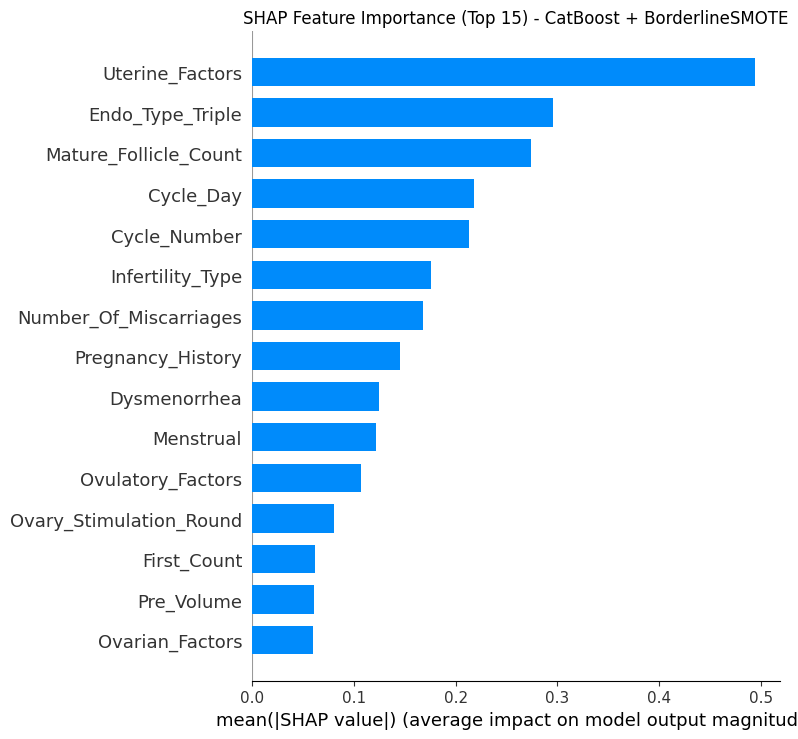

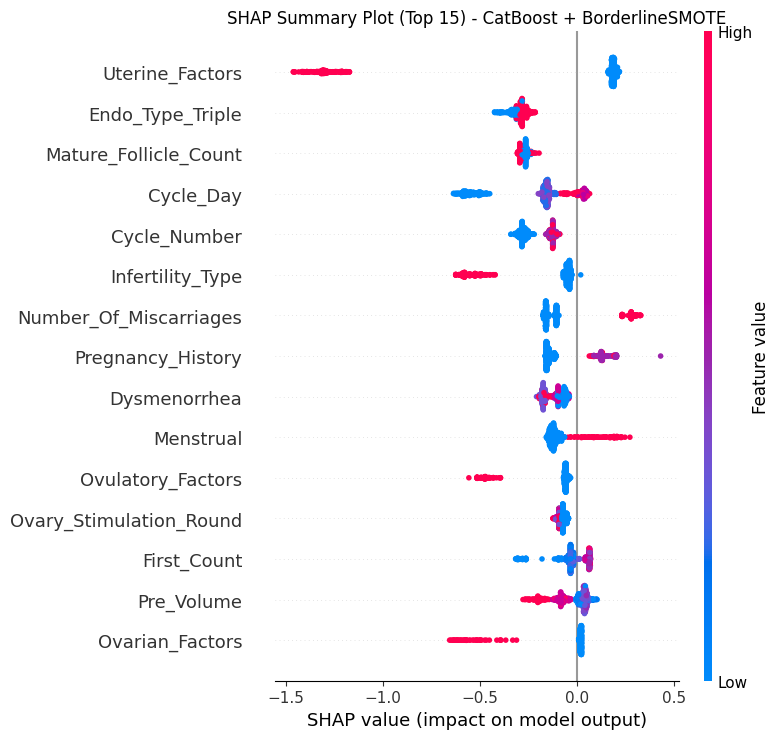

In [10]:
# ==========================================
# Block 6: SHAP Analysis for CatBoost + BorderlineSMOTE
# Purpose: rank features before feature budget optimization
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

os.makedirs('reports_ours/figures/shap_catboost', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)

# -----------------------------
# Best model pipeline
# -----------------------------
best_key = 'CatBoost__BorderlineSMOTE'

if best_key not in imbalance_models:
    raise ValueError(f"{best_key} not found in imbalance_models.")

best_pipeline = imbalance_models[best_key]['model']
cat_model = best_pipeline.named_steps['model']

# -----------------------------
# Prepare test data
# -----------------------------
X_test_shap = X_test.copy()

if 'feature_name_map' in globals():
    X_test_named = X_test_shap.rename(columns=feature_name_map)
else:
    X_test_named = X_test_shap.copy()

print("SHAP input shape:", X_test_shap.shape)

# -----------------------------
# SHAP values
# -----------------------------
# สำหรับ CatBoost ใช้ TreeExplainer ได้
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_shap)

# กันหลาย version ของ shap
if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# -----------------------------
# Feature importance table
# -----------------------------
feat_imp_catboost = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Feature_Display": X_test_named.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_imp_catboost.to_excel(
    "reports_ours/tables/SHAP_Feature_Importance_CatBoost_BorderlineSMOTE.xlsx",
    index=False
)

print("Top 15 SHAP features (CatBoost + BorderlineSMOTE)")
display(feat_imp_catboost.head(15))

# -----------------------------
# SHAP bar plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_named,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance (Top 15) - CatBoost + BorderlineSMOTE")
plt.tight_layout()
plt.savefig(
    "reports_ours/figures/shap_catboost/SHAP_Bar_Top15_CatBoost_BorderlineSMOTE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# -----------------------------
# SHAP beeswarm plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_named,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot (Top 15) - CatBoost + BorderlineSMOTE")
plt.tight_layout()
plt.savefig(
    "reports_ours/figures/shap_catboost/SHAP_Beeswarm_Top15_CatBoost_BorderlineSMOTE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### 4. Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด

Calculating Feature Budget for XGBoost + SMOTE
Max PR-AUC: 0.1333
Optimal number of features: 11

Selected features at optimal k:
1. Uterine_Factors
2. Endo_Type_Triple
3. Cycle_Day
4. hCG_Type
5. Dysmenorrhea
6. Infertility_Type
7. Number_Of_Miscarriages
8. Mature_Follicle_Count
9. Age_Female
10. Ovary_Stimulation_Round
11. Cycle_Number

Feature budget summary:
{'max_pr_auc': 0.13328433590833105, 'optimal_k': 11, 'selected_features': ['Uterine_Factors', 'Endo_Type_Triple', 'Cycle_Day', 'hCG_Type', 'Dysmenorrhea', 'Infertility_Type', 'Number_Of_Miscarriages', 'Mature_Follicle_Count', 'Age_Female', 'Ovary_Stimulation_Round', 'Cycle_Number']}


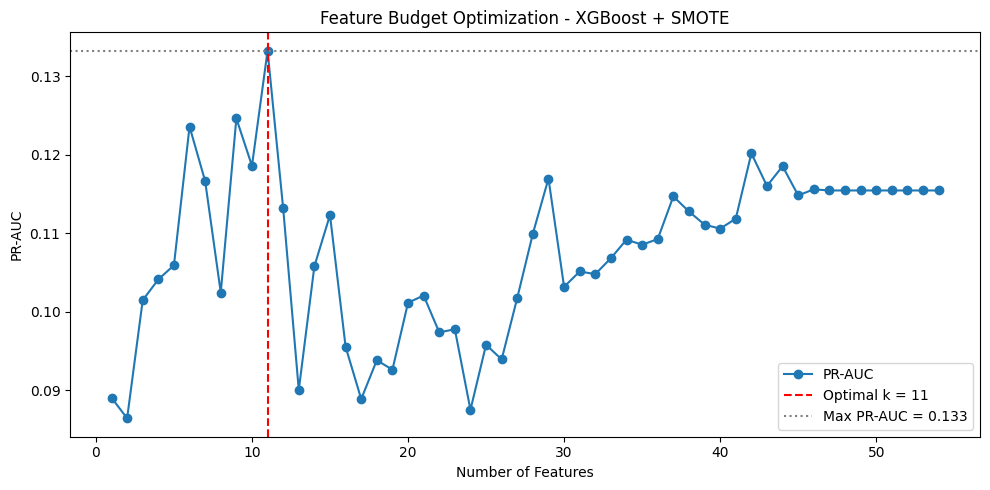


Top rows of feature-budget table:


,Num_Features,PR-AUC,ROC-AUC,Brier
0,1,0.089026,0.621293,0.245121
1,2,0.086392,0.606795,0.244224
2,3,0.101465,0.669372,0.217537
3,4,0.104111,0.662638,0.201545
4,5,0.105920,0.662397,0.148863
5,6,0.123610,0.682686,0.117692
6,7,0.116656,0.654764,0.114781
7,8,0.102442,0.638292,0.096700
8,9,0.124643,0.661278,0.069714
9,10,0.118603,0.654808,0.069197


In [82]:
# ==========================================
# Block 6B: Feature Budget Optimization
# Final ML model = XGBoost + SMOTE
# ==========================================

print("Calculating Feature Budget for XGBoost + SMOTE")

from sklearn.base import clone
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

os.makedirs('reports_ours/figures', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)

# -----------------------------
# Best ML model + feature ranking
# -----------------------------
if 'XGBoost__SMOTE' not in imbalance_models:
    raise ValueError("XGBoost__SMOTE not found in imbalance_models.")

if 'feat_imp_xgb' not in globals():
    raise ValueError("feat_imp_xgb not found. Please run SHAP feature importance block first.")

best_model_xgb = imbalance_models['XGBoost__SMOTE']['model']
top_features_xgb = feat_imp_xgb["Feature"].tolist()

if len(top_features_xgb) == 0:
    raise ValueError("No ranked features found in feat_imp_xgb.")

budget_rows_xgb = []

# -----------------------------
# Evaluate top-k feature subsets
# -----------------------------
for k in range(1, len(top_features_xgb) + 1):
    feats = top_features_xgb[:k]

    model_k = clone(best_model_xgb)
    model_k.fit(X_train[feats], y_train)

    probs_k = model_k.predict_proba(X_test[feats])[:, 1]

    pr_auc = average_precision_score(y_test, probs_k)
    roc_auc = roc_auc_score(y_test, probs_k)
    brier = brier_score_loss(y_test, probs_k)

    budget_rows_xgb.append({
        "Num_Features": k,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Brier": brier
    })

budget_df_xgb = pd.DataFrame(budget_rows_xgb)

# -----------------------------
# Choose smallest k within 0.005 of max PR-AUC
# -----------------------------
max_score_xgb = budget_df_xgb["PR-AUC"].max()

candidate_k = budget_df_xgb.loc[
    budget_df_xgb["PR-AUC"] >= (max_score_xgb - 0.005),
    "Num_Features"
]

if len(candidate_k) == 0:
    raise ValueError("No candidate k found within PR-AUC tolerance.")

optimal_k_xgb = int(candidate_k.iloc[0])
selected_features_xgb = top_features_xgb[:optimal_k_xgb]

print(f"Max PR-AUC: {max_score_xgb:.4f}")
print(f"Optimal number of features: {optimal_k_xgb}")

print("\nSelected features at optimal k:")
for i, f in enumerate(selected_features_xgb, start=1):
    print(f"{i}. {f}")

# -----------------------------
# Save tables
# -----------------------------
budget_df_xgb.to_excel(
    "reports_ours/tables/Feature_Budget_Scores_XGBoost_SMOTE.xlsx",
    index=False
)

selected_features_xgb_df = pd.DataFrame({
    "Rank": range(1, optimal_k_xgb + 1),
    "Selected_Feature": selected_features_xgb
})
selected_features_xgb_df.to_excel(
    "reports_ours/tables/Selected_Features_OptimalK_XGBoost_SMOTE.xlsx",
    index=False
)

# -----------------------------
# Save compact summary
# -----------------------------
feature_budget_summary_xgb = {
    "max_pr_auc": float(max_score_xgb),
    "optimal_k": int(optimal_k_xgb),
    "selected_features": selected_features_xgb
}

print("\nFeature budget summary:")
print(feature_budget_summary_xgb)

# -----------------------------
# Plot PR-AUC curve
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    budget_df_xgb["Num_Features"],
    budget_df_xgb["PR-AUC"],
    marker="o",
    label="PR-AUC"
)

plt.axvline(
    x=optimal_k_xgb,
    linestyle="--",
    color="red",
    label=f"Optimal k = {optimal_k_xgb}"
)

plt.axhline(
    y=max_score_xgb,
    linestyle=":",
    color="gray",
    label=f"Max PR-AUC = {max_score_xgb:.3f}"
)

plt.xlabel("Number of Features")
plt.ylabel("PR-AUC")
plt.title("Feature Budget Optimization - XGBoost + SMOTE")
plt.legend()
plt.tight_layout()

plt.savefig(
    "reports_ours/figures/Feature_Budget_Optimization_XGBoost_SMOTE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -----------------------------
# Preview results
# -----------------------------
print("\nTop rows of feature-budget table:")
display(budget_df_xgb.head(15))

Final features used for retraining:
1. Uterine_Factors
2. Endo_Type_Triple
3. Cycle_Day
4. hCG_Type
5. Dysmenorrhea
6. Infertility_Type
7. Number_Of_Miscarriages
8. Mature_Follicle_Count
9. Age_Female
10. Ovary_Stimulation_Round
11. Cycle_Number

Final model performance on test set:
PR-AUC:  0.1333
ROC-AUC: 0.6386
Brier:   0.0688

Top SHAP features (Final XGBoost + SMOTE model)


,Feature,Feature_Display,Importance
0,Uterine_Factors,Uterine Factors,0.546640
1,Dysmenorrhea,Dysmenorrhea,0.370080
2,Age_Female,Female Age,0.295260
3,hCG_Type,hCG Trigger Type,0.294392
4,Mature_Follicle_Count,Number of Mature Follicles,0.291935
5,Cycle_Number,IUI Cycle Number,0.250128
6,Cycle_Day,Cycle Day,0.241760
7,Endo_Type_Triple,Triple-line Endometrium,0.209468
8,Ovary_Stimulation_Round,Ovarian Stimulation Round,0.165711
9,Number_Of_Miscarriages,Number of Previous Miscarriages,0.129867


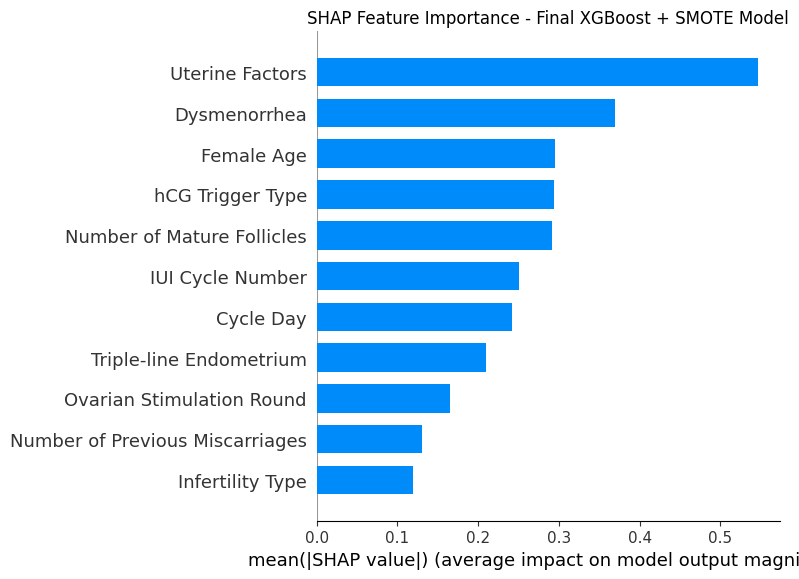

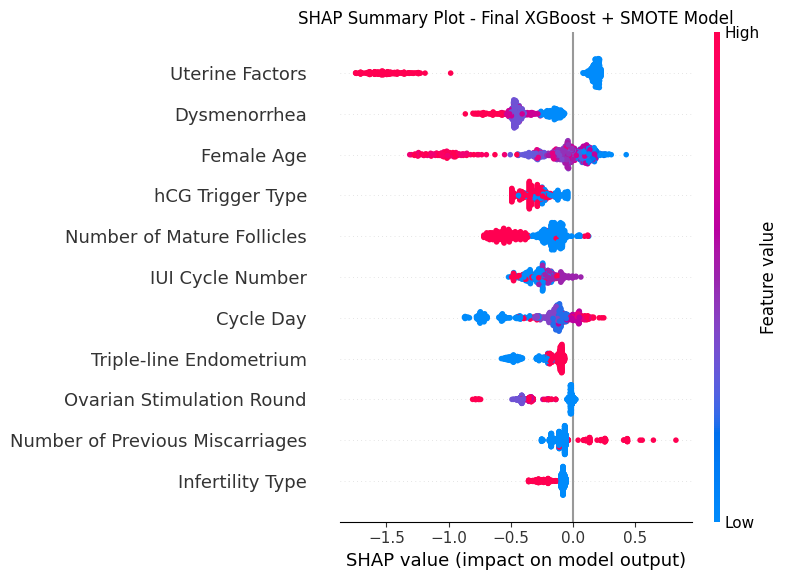

In [85]:
# ==========================================
# Block 7: Retrain Final Model + SHAP Analysis
# Final model = XGBoost + SMOTE after feature budget
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.base import clone
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

os.makedirs('reports_ours/figures/shap_final_xgb', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('models_ours/final_model', exist_ok=True)

# -----------------------------
# Final feature set from feature budget
# -----------------------------
if 'selected_features_xgb' not in globals():
    raise ValueError("selected_features_xgb not found. Please run Block 6B first.")

final_features = selected_features_xgb.copy()

print("Final features used for retraining:")
for i, f in enumerate(final_features, start=1):
    print(f"{i}. {f}")

# -----------------------------
# Retrain final model
# -----------------------------
if 'XGBoost__SMOTE' not in imbalance_models:
    raise ValueError("XGBoost__SMOTE not found in imbalance_models.")

final_model = clone(imbalance_models['XGBoost__SMOTE']['model'])
final_model.fit(X_train[final_features], y_train)

# Save model
joblib.dump(
    final_model,
    "models_ours/final_model/XGBoost_SMOTE_final_feature_budget_model.joblib"
)

# -----------------------------
# Final model probabilities
# -----------------------------
final_probs = final_model.predict_proba(X_test[final_features])[:, 1]

final_pr_auc = average_precision_score(y_test, final_probs)
final_roc_auc = roc_auc_score(y_test, final_probs)
final_brier = brier_score_loss(y_test, final_probs)

print("\nFinal model performance on test set:")
print(f"PR-AUC:  {final_pr_auc:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Brier:   {final_brier:.4f}")

# -----------------------------
# Save final performance summary
# -----------------------------
final_model_summary = pd.DataFrame([{
    "Model": "XGBoost + SMOTE (Final Feature-Budget Model)",
    "Num_Features": len(final_features),
    "Features": ", ".join(final_features),
    "PR-AUC": final_pr_auc,
    "ROC-AUC": final_roc_auc,
    "Brier": final_brier
}])

final_model_summary.to_excel(
    "reports_ours/tables/Final_Model_Performance_XGBoost_SMOTE.xlsx",
    index=False
)

# -----------------------------
# Prepare feature names for display
# -----------------------------
if 'feature_name_map' in globals():
    X_test_final_named = X_test[final_features].rename(columns=feature_name_map)
else:
    X_test_final_named = X_test[final_features].copy()

# -----------------------------
# SHAP explainer
# -----------------------------
xgb_model_final = final_model.named_steps['model']
explainer = shap.TreeExplainer(xgb_model_final)
shap_values = explainer.shap_values(X_test[final_features])

# Handle SHAP version differences
if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# -----------------------------
# SHAP feature importance table
# -----------------------------
feat_imp_final_xgb = pd.DataFrame({
    "Feature": final_features,
    "Feature_Display": X_test_final_named.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_imp_final_xgb.to_excel(
    "reports_ours/tables/SHAP_Feature_Importance_Final_XGBoost_SMOTE.xlsx",
    index=False
)

print("\nTop SHAP features (Final XGBoost + SMOTE model)")
display(feat_imp_final_xgb)

# -----------------------------
# SHAP bar plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    plot_type="bar",
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Feature Importance - Final XGBoost + SMOTE Model")
plt.tight_layout()
plt.savefig(
    "reports_ours/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_SMOTE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# -----------------------------
# SHAP beeswarm plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Summary Plot - Final XGBoost + SMOTE Model")
plt.tight_layout()
plt.savefig(
    "reports_ours/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_SMOTE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

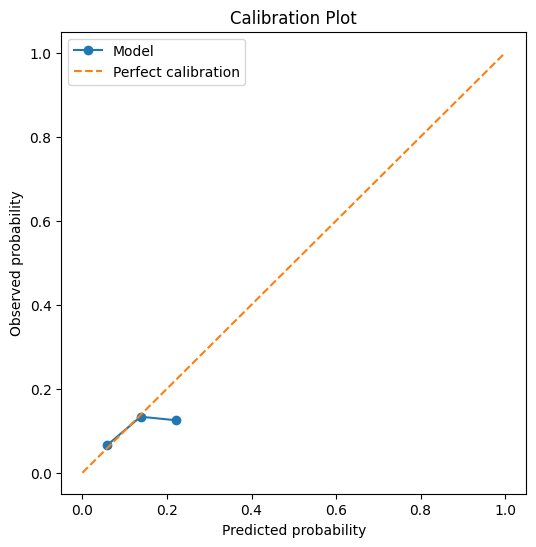

In [40]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    final_probs,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration Plot")

plt.legend()
plt.show()

Dependence features to plot: ['Uterine_Factors', 'Age_Female', 'First_Count', 'FSH_Baseline', 'Pre_Motile', 'Menstrual_Interval_Days', 'Post_TPMSC', 'Gynecological_Surgical_History', 'Alcohol', 'First_Volume']


<Figure size 800x600 with 0 Axes>

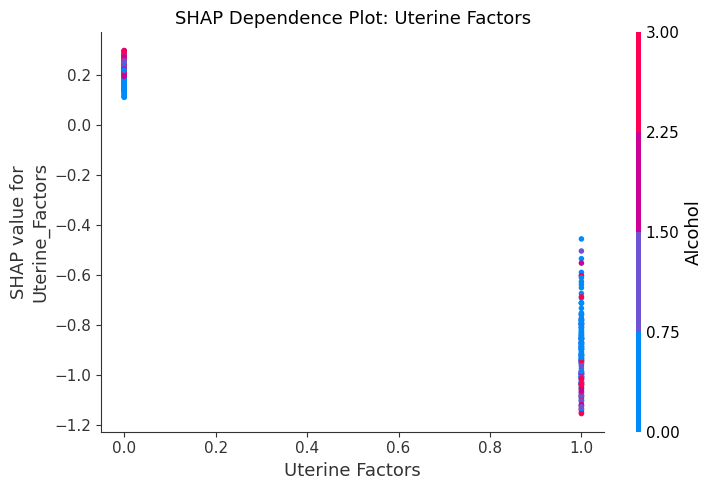

<Figure size 800x600 with 0 Axes>

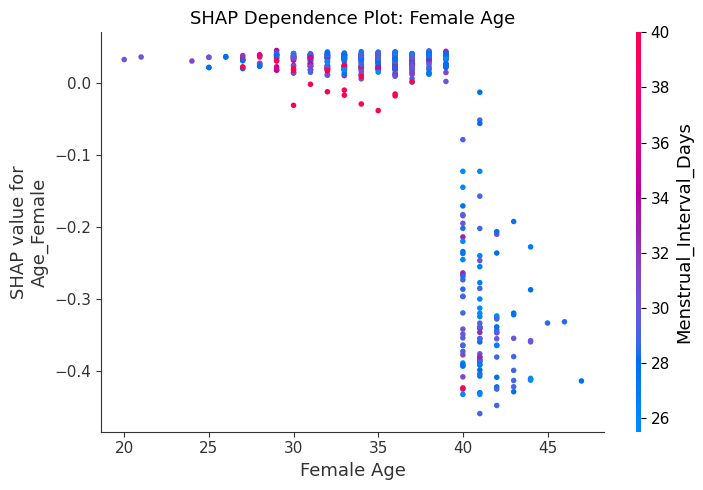

<Figure size 800x600 with 0 Axes>

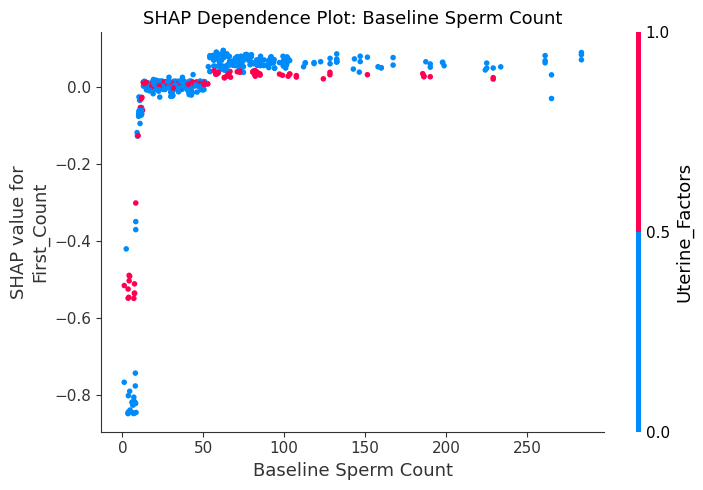

<Figure size 800x600 with 0 Axes>

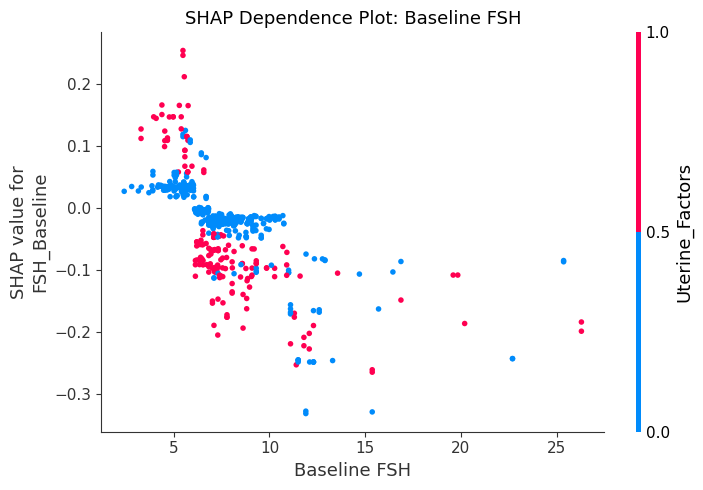

<Figure size 800x600 with 0 Axes>

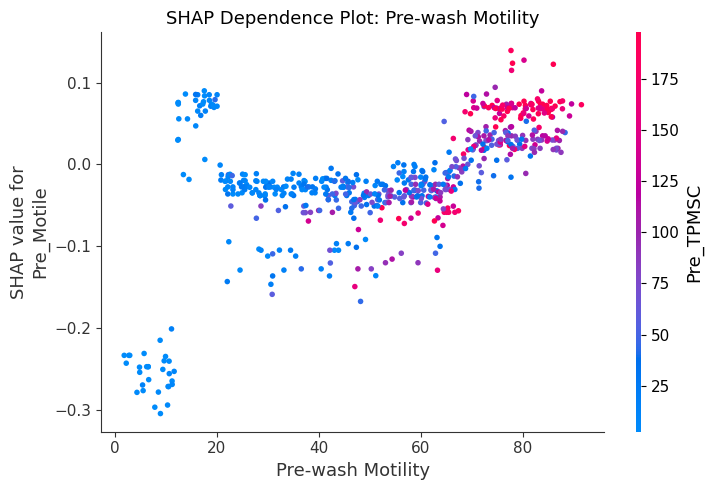

<Figure size 800x600 with 0 Axes>

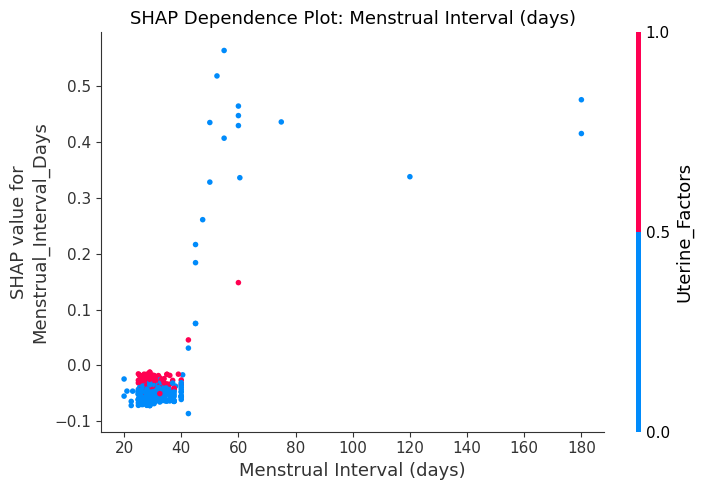

<Figure size 800x600 with 0 Axes>

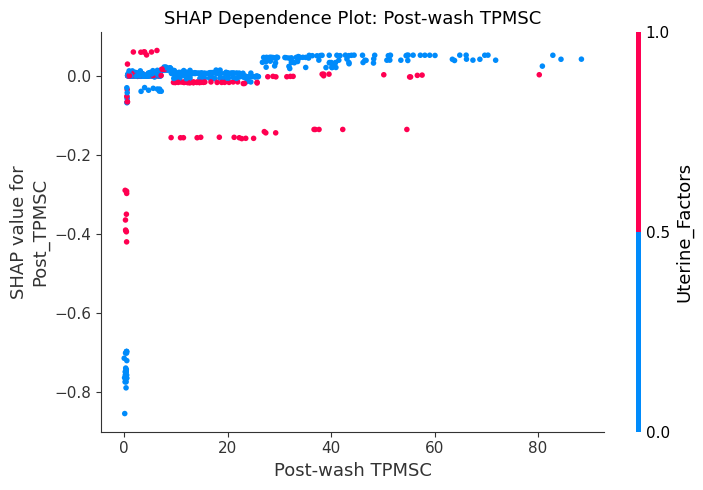

<Figure size 800x600 with 0 Axes>

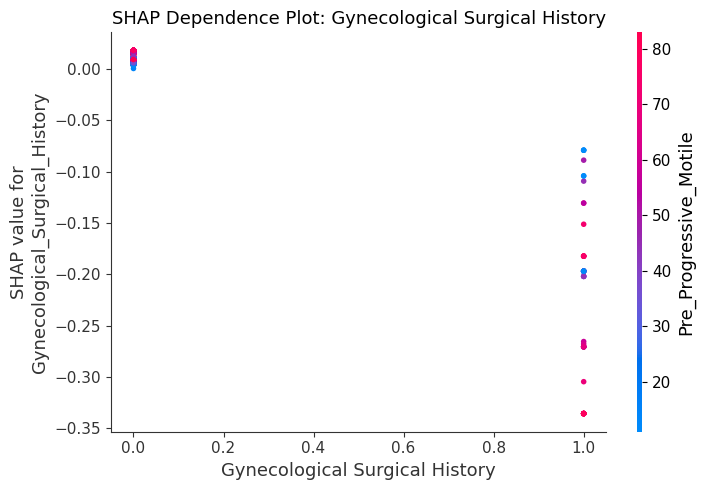

<Figure size 800x600 with 0 Axes>

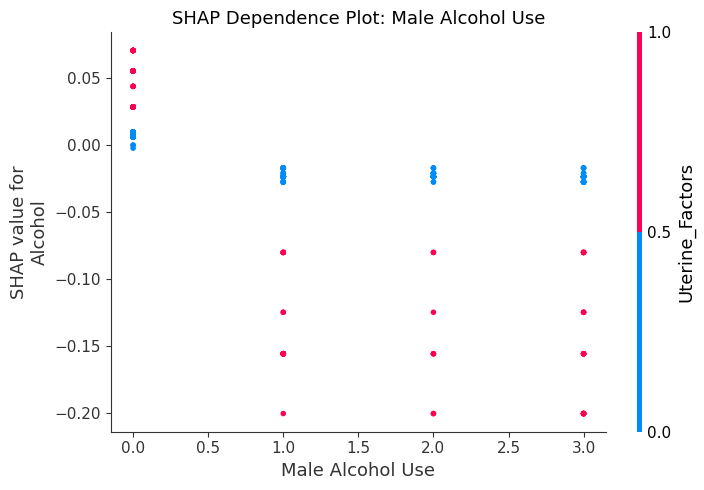

<Figure size 800x600 with 0 Axes>

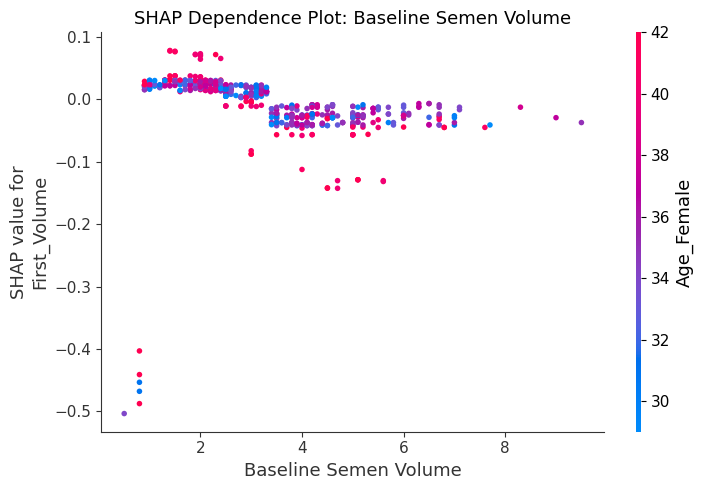

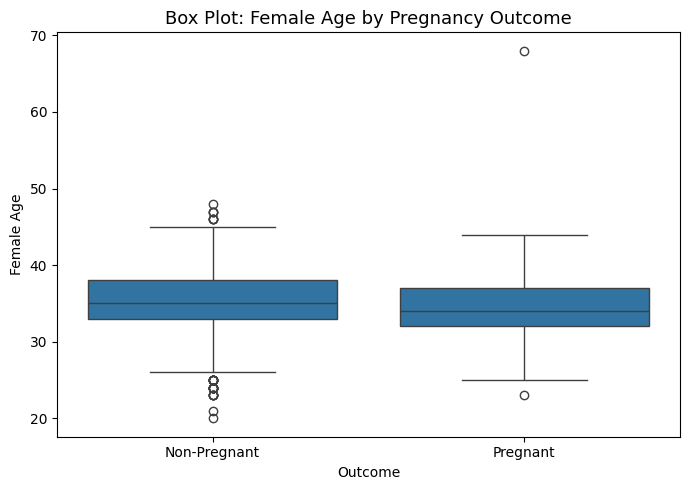

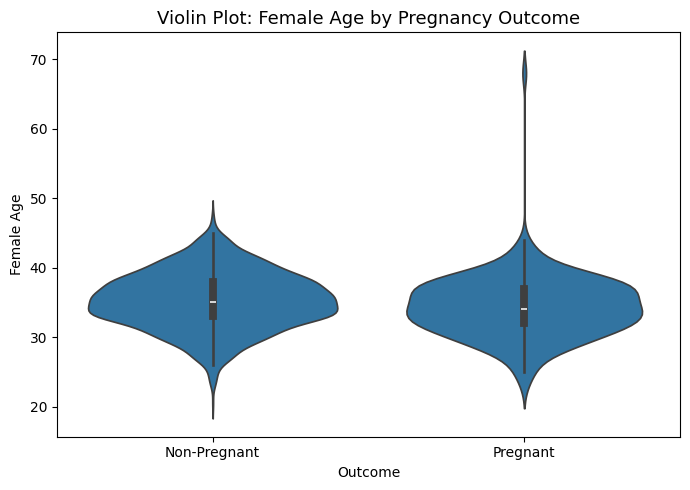

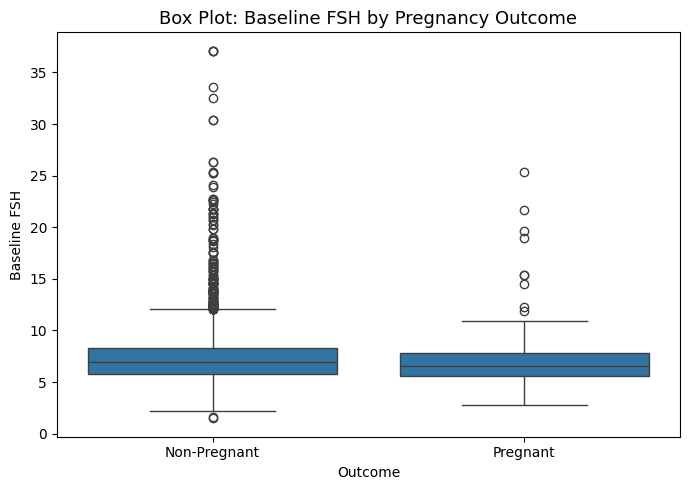

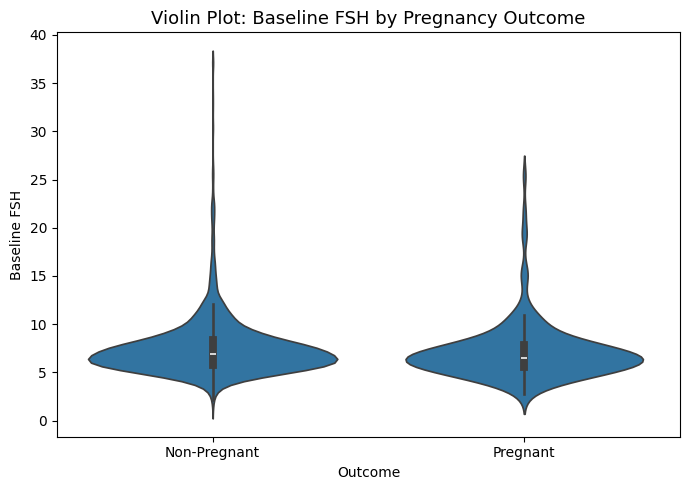

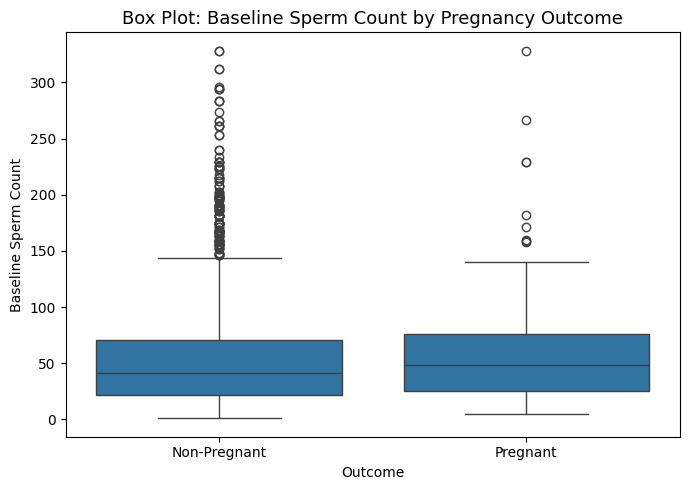

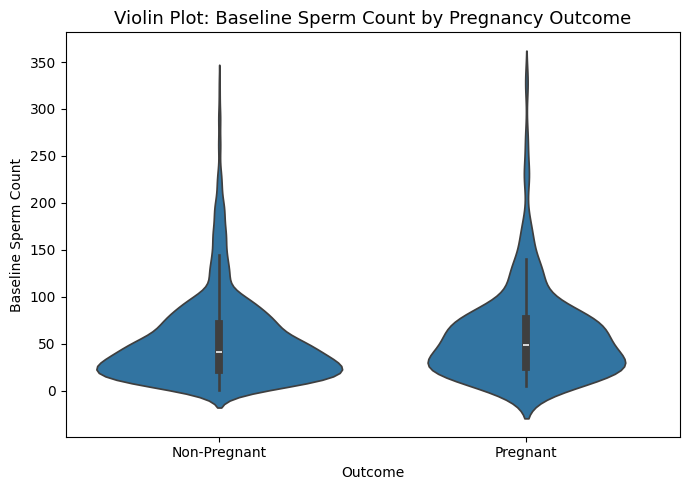

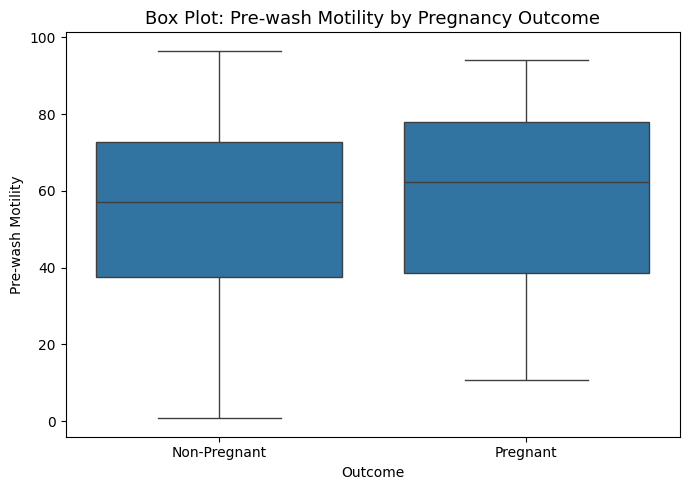

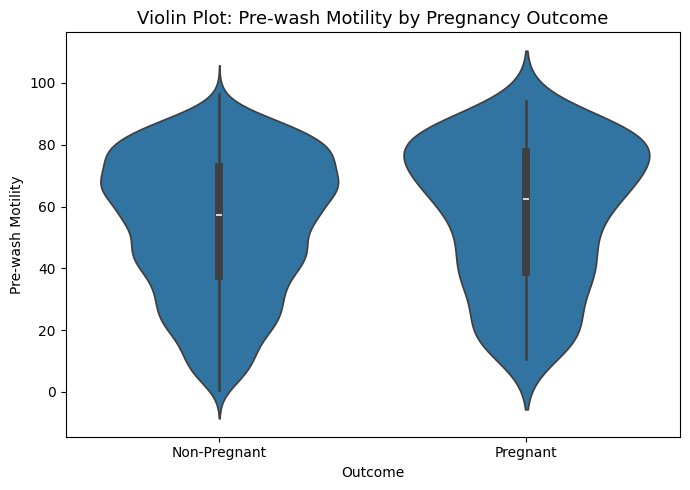

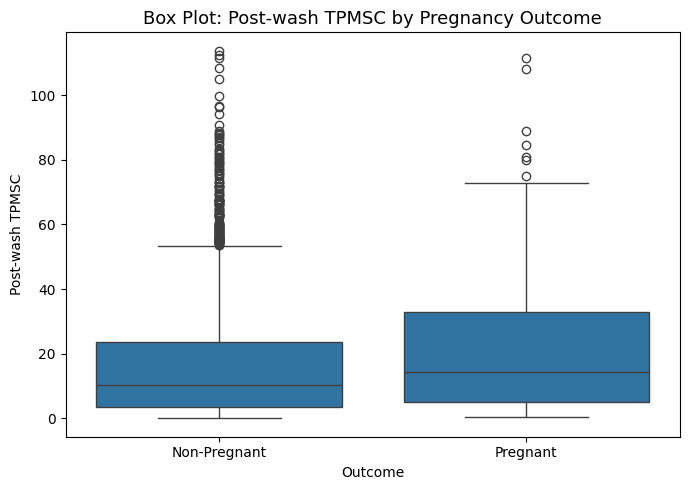

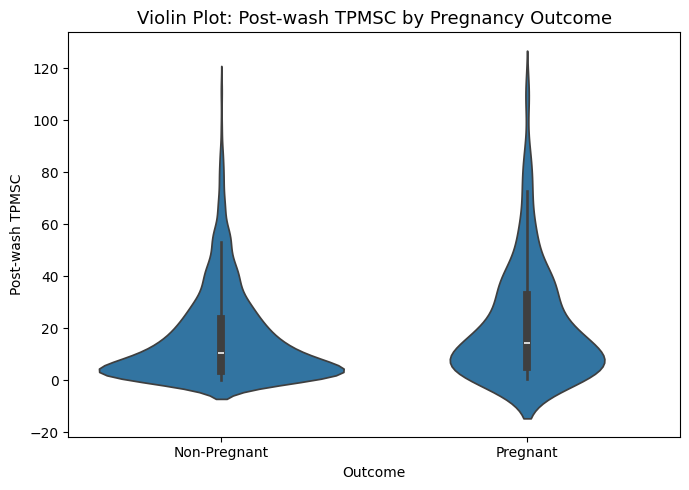

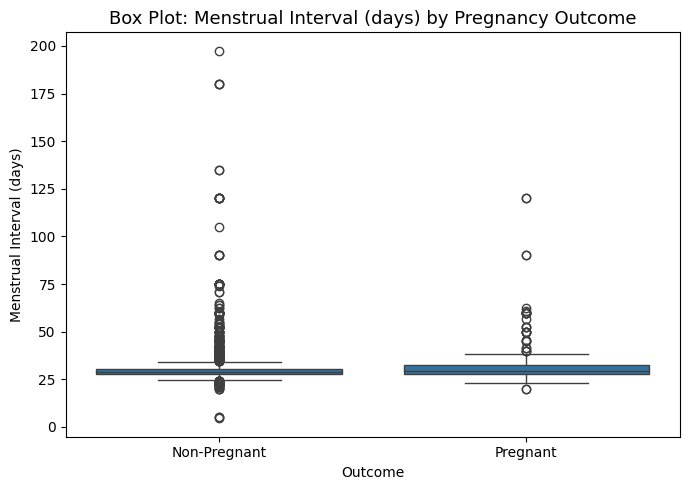

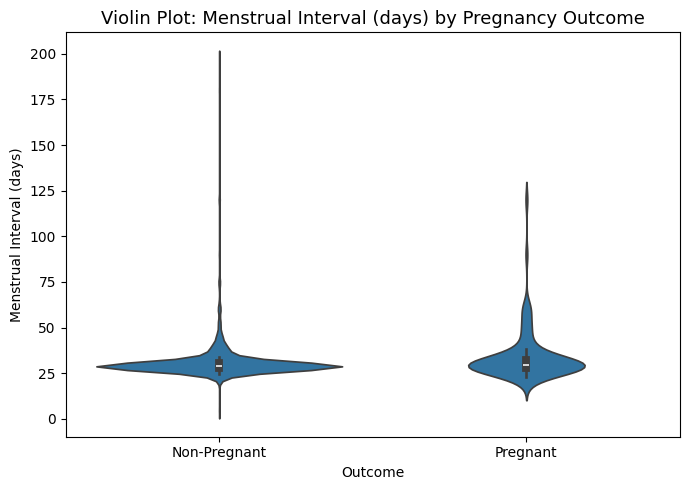

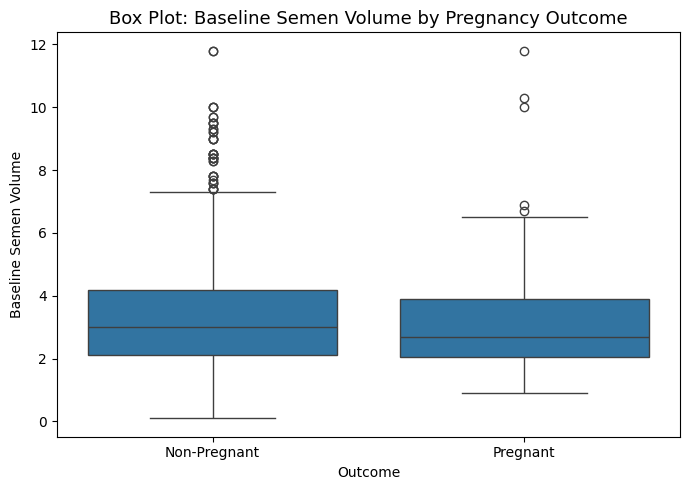

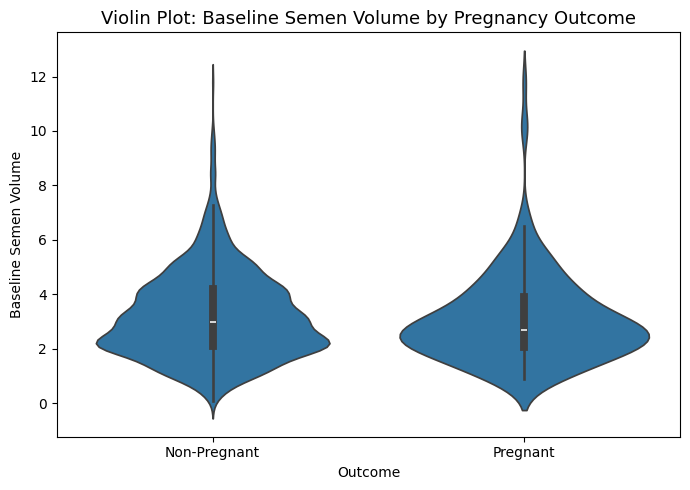

<Figure size 800x600 with 0 Axes>

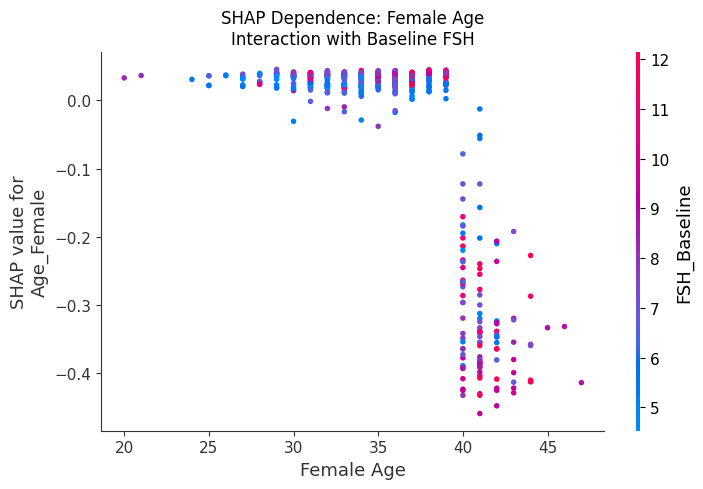

In [10]:
# =========================
# 4.3 SHAP Dependence Plots
# =========================
import os

os.makedirs('reports_ours/figures/shap_dependence', exist_ok=True)
os.makedirs('reports_ours/figures/clinical_plots', exist_ok=True)

# เลือก dependence plots จาก feature ที่สำคัญจริงตาม SHAP ล่าสุด
candidate_dependence_features = [
    'Uterine_Factors',
    'Age_Female',
    'First_Count',
    'FSH_Baseline',
    'Pre_Motile',
    'Menstrual_Interval_Days',
    'Post_TPMSC',
    'Gynecological_Surgical_History',
    'Alcohol',
    'First_Volume'
]

# เอาเฉพาะตัวที่มีอยู่จริงใน X_test และอยู่ใน top SHAP features
top_feature_set = set(feat_imp['Feature'].head(15).tolist())
dependence_features = [
    f for f in candidate_dependence_features
    if f in X_test.columns and f in top_feature_set
]

print("Dependence features to plot:", dependence_features)

for feat in dependence_features:
    display_name = feature_name_map.get(feat, feat)

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        feat,
        shap_v,
        X_test,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {display_name}', fontsize=13)
    plt.xlabel(display_name)
    plt.tight_layout()
    plt.savefig(
        f'reports_ours/figures/shap_dependence/SHAP_Dependence_{feat}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()


# ==========================================
# 4.4 Clinical Box / Violin Plots by Outcome
# ==========================================

plot_df = df.copy()
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]

# ให้ Result เป็น numeric ชัวร์
plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df = plot_df.dropna(subset=['Result'])

# ทำ label ให้อ่านง่าย
plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

# เน้นตัวที่เข้ากับ SHAP และเล่า biology ได้
clinical_plot_features = [
    'Age_Female',
    'FSH_Baseline',
    'First_Count',
    'Pre_Motile',
    'Post_TPMSC',
    'Menstrual_Interval_Days',
    'First_Volume'
]

for feat in clinical_plot_features:
    if feat in plot_df.columns:
        display_name = feature_name_map.get(feat, feat)

        tmp = plot_df[['Pregnancy_Label', feat]].copy()
        tmp[feat] = pd.to_numeric(tmp[feat], errors='coerce')
        tmp = tmp.dropna(subset=[feat, 'Pregnancy_Label'])

        if tmp.empty:
            print(f"⚠️ ไม่มีข้อมูลใช้ plot สำหรับ {feat}")
            continue

        # Boxplot
        plt.figure(figsize=(7, 5))
        sns.boxplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat
        )
        plt.title(f'Box Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_ours/figures/clinical_plots/BoxPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()

        # Violin plot
        plt.figure(figsize=(7, 5))
        sns.violinplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat,
            inner='box'
        )
        plt.title(f'Violin Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_ours/figures/clinical_plots/ViolinPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
    else:
        print(f"⚠️ ไม่พบคอลัมน์ {feat} ใน plot_df เลยข้ามไป")


# ==========================================
# 4.5 Selected SHAP Interaction Plot
# ==========================================
# ปรับให้เข้ากับผลลัพธ์ล่าสุด: Age_Female × FSH_Baseline

if {'Age_Female', 'FSH_Baseline'}.issubset(X_test.columns):
    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        'Age_Female',
        shap_v,
        X_test,
        interaction_index='FSH_Baseline',
        show=False
    )

    plt.title('SHAP Dependence: Female Age\nInteraction with Baseline FSH')
    plt.xlabel('Female Age')
    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/shap_dependence/SHAP_Dependence_FemaleAge_interaction_FSH_Baseline.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
else:
    print("⚠️ ไม่พบ Age_Female หรือ FSH_Baseline ใน X_test")

In [41]:
from sklearn.linear_model import LogisticRegression

lr_cal = LogisticRegression()

lr_cal.fit(
    final_probs.reshape(-1,1),
    y_test
)

final_probs_calibrated = lr_cal.predict_proba(
    final_probs.reshape(-1,1)
)[:,1]

### 5. Clinical Analysis 1: Risk Stratification

Risk tiers present: ['Tier 2 (Intermediate Probability)', 'Tier 1 (Low Probability)', 'Tier 3 (High Probability)']
Categories (3, object): ['Tier 1 (Low Probability)' < 'Tier 2 (Intermediate Probability)' < 'Tier 3 (High Probability)']


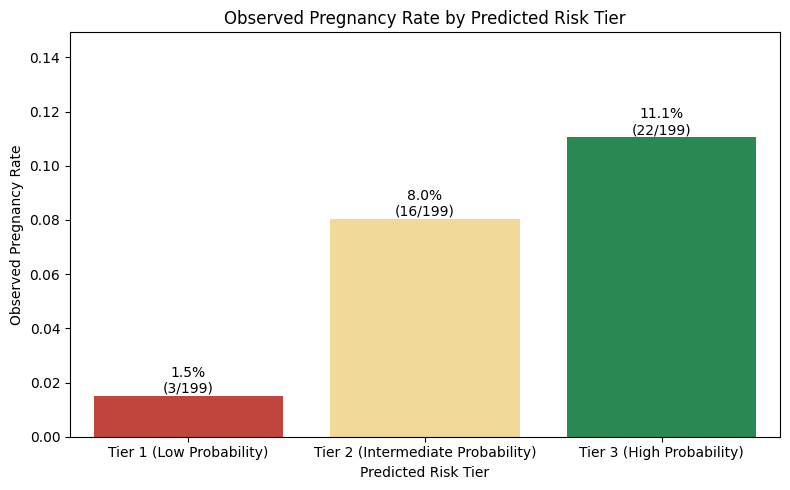


Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           199                   3   
1  Tier 2 (Intermediate Probability)           199                  16   
2          Tier 3 (High Probability)           199                  22   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.033614            0.021928            0.055006   
1            0.067455            0.055655            0.070992   
2            0.088940            0.071026            0.244675   

   Unique_Patients  Observed_Pregnancy_Rate  Predicted_minus_Observed  
0              129                 0.015075                  0.018539  
1              119                 0.080402                 -0.012947  
2              131                 0.110553                 -0.021613  


In [42]:
# =========================
# Block 8: Risk Tier Analysis
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

test_info = test_info.copy()
test_info['Predicted_Prob'] = final_probs
test_info['Actual_Result'] = y_test.values

# กัน missing
test_info = test_info.dropna(subset=['Predicted_Prob', 'Actual_Result']).copy()

# --------------------------------
# Create risk tiers using tertiles
# --------------------------------
tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

test_info['Risk_Tier'] = pd.qcut(
    test_info['Predicted_Prob'],
    q=3,
    labels=tier_labels,
    duplicates='drop'
)

print("Risk tiers present:", test_info['Risk_Tier'].dropna().unique())

# --------------------------------
# Summary table
# --------------------------------
tier_summary = (
    test_info
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

if 'HN' in test_info.columns:
    patient_counts = (
        test_info
        .groupby('Risk_Tier', observed=False)['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )
    tier_summary = tier_summary.merge(patient_counts, on='Risk_Tier', how='left')

tier_summary['Observed_Pregnancy_Rate'] = (
    tier_summary['Actual_Pregnancies'] / tier_summary['Total_Cycles']
)

tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] - tier_summary['Observed_Pregnancy_Rate']
)

# จัดลำดับ tier ให้คงที่
tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'],
    categories=tier_labels,
    ordered=True
)
tier_summary = tier_summary.sort_values('Risk_Tier').reset_index(drop=True)

# save table
tier_summary.to_excel(
    'reports_ours/tables/Risk_Tier_Summary_FinalModel.xlsx',
    index=False
)

# --------------------------------
# Plot clinical risk stratification
# --------------------------------
tier_colors = ['#d73027', '#fee08b', '#1a9850']

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Risk_Tier',
    y='Observed_Pregnancy_Rate',
    data=tier_summary,
    palette=tier_colors
)

plt.title('Observed Pregnancy Rate by Predicted Risk Tier')
plt.ylabel('Observed Pregnancy Rate')
plt.xlabel('Predicted Risk Tier')

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
plt.ylim(0, max(ymax * 1.35, 0.05))

for index, row in tier_summary.iterrows():
    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )
    plt.text(
        index,
        row['Observed_Pregnancy_Rate'],
        label,
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'reports_ours/figures/clinical/Risk_Tier_Analysis_FinalModel.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nRisk Tier Summary:")
print(tier_summary)

### 6. Clinical Analysis 2: Cumulative Cycle Impact

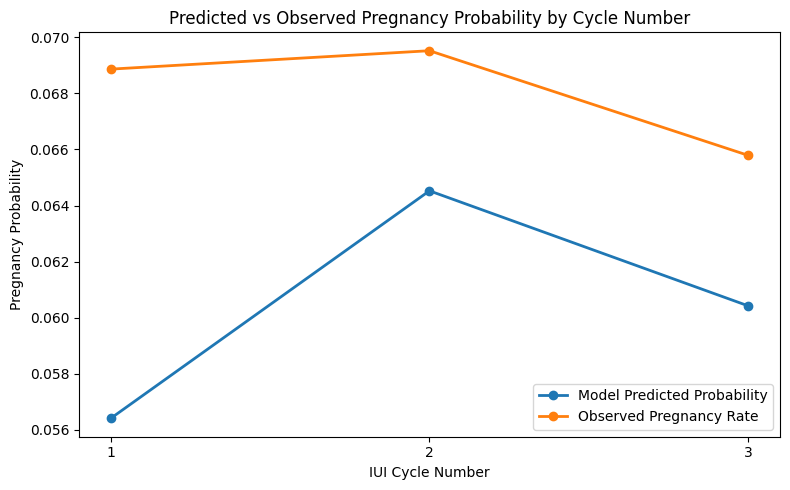


Cycle Summary:
   Cycle_Number  Total_Cycles  Actual_Pregnancies  Avg_Predicted_Prob  \
0             1           334                  23            0.056415   
1             2           187                  13            0.064525   
2             3            76                   5            0.060425   

   Observed_Pregnancy_Rate  
0                 0.068862  
1                 0.069519  
2                 0.065789  


In [14]:
# =========================
# 6. Cycle Number Analysis
# =========================

import os

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

if 'Cycle_Number' in test_info.columns:

    cycle_summary = (
        test_info
        .groupby('Cycle_Number')
        .agg(
            Total_Cycles=('Actual_Result', 'count'),
            Actual_Pregnancies=('Actual_Result', 'sum'),
            Avg_Predicted_Prob=('Predicted_Prob', 'mean')
        )
        .reset_index()
    )

    cycle_summary['Observed_Pregnancy_Rate'] = (
        cycle_summary['Actual_Pregnancies'] /
        cycle_summary['Total_Cycles']
    )

    # ใช้เฉพาะ cycle 1–3
    cycle_summary = cycle_summary[cycle_summary['Cycle_Number'] <= 3]

    # save table
    cycle_summary.to_excel(
        'reports_ours/tables/Cycle_Number_Summary.xlsx',
        index=False
    )

    # ---------------------
    # Plot comparison figure
    # ---------------------

    plt.figure(figsize=(8,5))

    plt.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Avg_Predicted_Prob'],
        marker='o',
        linewidth=2,
        label='Model Predicted Probability'
    )

    plt.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Observed_Pregnancy_Rate'],
        marker='o',
        linewidth=2,
        label='Observed Pregnancy Rate'
    )

    plt.xticks([1,2,3])
    plt.xlabel('IUI Cycle Number')
    plt.ylabel('Pregnancy Probability')

    plt.title('Predicted vs Observed Pregnancy Probability by Cycle Number')

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cycle_Number_Analysis.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    print("\nCycle Summary:")
    print(cycle_summary)

else:
    print("ไม่มีตัวแปร Cycle_Number ให้วิเคราะห์")


CUMULATIVE PREGNANCY SUMMARY
{'Patients': 353, 'Avg_Predicted_Cumulative_Prob': np.float64(0.09548562336905485), 'Observed_Pregnancy_Rate': np.float64(0.11614730878186968)}


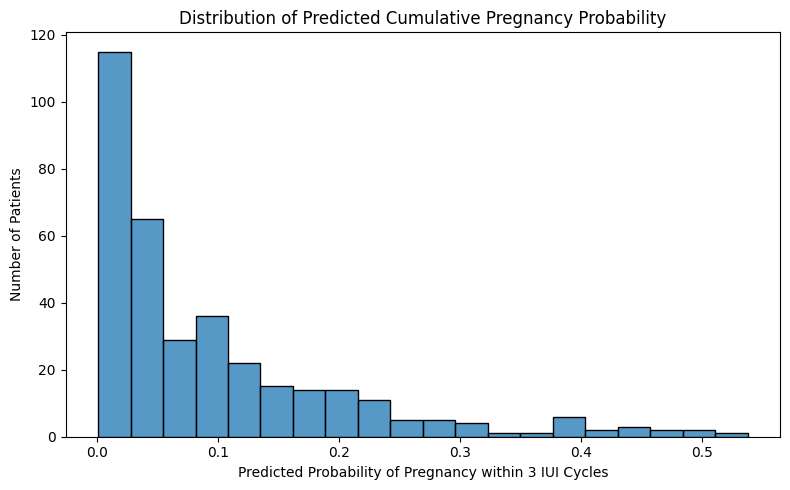

In [16]:
# ===============================
# 7. CUMULATIVE PREGNANCY ANALYSIS
# ===============================

import os

os.makedirs('reports_ours/figures/clinical', exist_ok=True)
os.makedirs('reports_ours/tables', exist_ok=True)

if 'Cycle_Number' in test_info.columns:

    # ใช้เฉพาะ cycle 1-3
    cum_df = test_info[test_info['Cycle_Number'] <= 3].copy()

    # sort เพื่อความถูกต้อง
    cum_df = cum_df.sort_values(['HN','Cycle_Number'])

    # -----------------------------
    # cumulative predicted pregnancy
    # -----------------------------

    cumulative_results = []

    for hn, g in cum_df.groupby('HN'):

        g = g.sort_values('Cycle_Number')

        p = g['Predicted_Prob'].values

        # cumulative probability
        cum_prob = 1 - np.prod(1 - p)

        cumulative_results.append({
            'HN': hn,
            'Num_Cycles': len(g),
            'Cumulative_Predicted_Prob': cum_prob,
            'Actual_Pregnancy': g['Actual_Result'].max()
        })

    cumulative_df = pd.DataFrame(cumulative_results)

    cumulative_df.to_excel(
        'reports_ours/tables/Cumulative_Patient_Level.xlsx',
        index=False
    )

    # -----------------------------
    # summary
    # -----------------------------

    cumulative_summary = {
        "Patients": len(cumulative_df),
        "Avg_Predicted_Cumulative_Prob": cumulative_df['Cumulative_Predicted_Prob'].mean(),
        "Observed_Pregnancy_Rate": cumulative_df['Actual_Pregnancy'].mean()
    }

    print("\nCUMULATIVE PREGNANCY SUMMARY")
    print(cumulative_summary)

    # -----------------------------
    # plot distribution
    # -----------------------------

    plt.figure(figsize=(8,5))

    sns.histplot(
        cumulative_df['Cumulative_Predicted_Prob'],
        bins=20
    )

    plt.xlabel('Predicted Probability of Pregnancy within 3 IUI Cycles')
    plt.ylabel('Number of Patients')
    plt.title('Distribution of Predicted Cumulative Pregnancy Probability')

    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cumulative_Pregnancy_Distribution.png',
        dpi=300
    )

    plt.show()

else:
    print("Cycle_Number not available")


Cumulative Success Summary:
   Cycle  Actual_Cumulative_Pregnancy_Rate  \
0      1                          0.065156   
1      2                          0.101983   
2      3                          0.116147   

   Predicted_Cumulative_Pregnancy_Rate  
0                             0.056707  
1                             0.085540  
2                             0.095486  


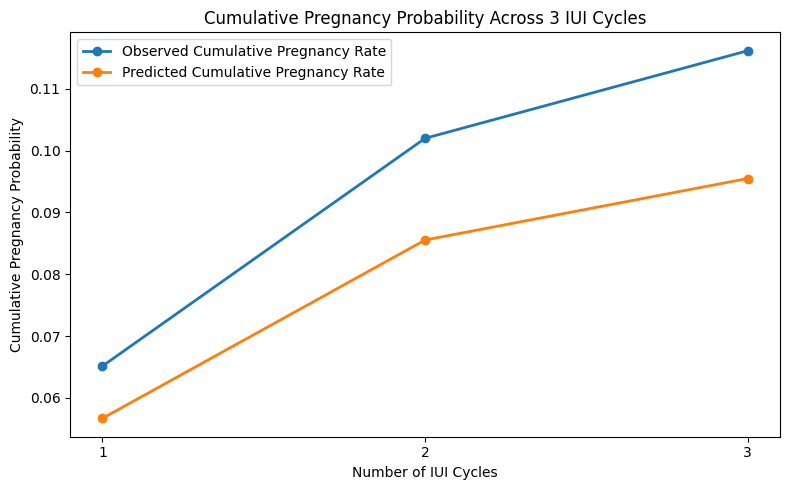

In [17]:
# =========================================
# 8. COHORT-LEVEL CUMULATIVE SUCCESS (1-3)
# =========================================

import os

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

if 'Cycle_Number' in test_info.columns and 'HN' in test_info.columns:

    cum_plot_df = test_info.copy()
    cum_plot_df['Actual_Result'] = y_test.values
    cum_plot_df['Predicted_Prob'] = final_probs_opt

    # ใช้เฉพาะ 3 cycles แรก
    cum_plot_df = cum_plot_df[cum_plot_df['Cycle_Number'] <= 3].copy()
    cum_plot_df = cum_plot_df.sort_values(['HN', 'Cycle_Number'])

    # -----------------------------
    # Actual cumulative pregnancy
    # -----------------------------
    actual_rows = []

    # รายชื่อคนไข้ใน test set
    patient_ids = cum_plot_df['HN'].dropna().unique()

    for k in [1, 2, 3]:
        sub = cum_plot_df[cum_plot_df['Cycle_Number'] <= k].copy()

        # คนไข้ที่มี pregnancy ภายใน <= k cycles
        preg_by_k = (
            sub.groupby('HN')['Actual_Result']
            .max()
            .reindex(patient_ids, fill_value=0)
        )

        actual_rows.append({
            'Cycle': k,
            'Actual_Cumulative_Pregnancy_Rate': preg_by_k.mean()
        })

    actual_cum_df = pd.DataFrame(actual_rows)

    # -----------------------------
    # Predicted cumulative pregnancy
    # -----------------------------
    pred_rows = []

    for k in [1, 2, 3]:
        sub = cum_plot_df[cum_plot_df['Cycle_Number'] <= k].copy()

        patient_pred = []

        for hn in patient_ids:
            g = sub[sub['HN'] == hn].sort_values('Cycle_Number')

            if len(g) == 0:
                # ถ้าคนนี้ยังไม่มีข้อมูลถึง cycle นี้ ให้ข้าม
                continue

            p = g['Predicted_Prob'].values
            cum_prob = 1 - np.prod(1 - p)

            patient_pred.append(cum_prob)

        pred_rows.append({
            'Cycle': k,
            'Predicted_Cumulative_Pregnancy_Rate': np.mean(patient_pred)
        })

    pred_cum_df = pd.DataFrame(pred_rows)

    # -----------------------------
    # Merge summary
    # -----------------------------
    cumulative_summary_df = actual_cum_df.merge(pred_cum_df, on='Cycle')

    cumulative_summary_df.to_excel(
        'reports_ours/tables/Cumulative_Success_By_Cycle.xlsx',
        index=False
    )

    print("\nCumulative Success Summary:")
    print(cumulative_summary_df)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Actual_Cumulative_Pregnancy_Rate'],
        marker='o',
        linewidth=2,
        label='Observed Cumulative Pregnancy Rate'
    )

    plt.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Predicted_Cumulative_Pregnancy_Rate'],
        marker='o',
        linewidth=2,
        label='Predicted Cumulative Pregnancy Rate'
    )

    plt.xticks([1, 2, 3])
    plt.xlabel('Number of IUI Cycles')
    plt.ylabel('Cumulative Pregnancy Probability')
    plt.title('Cumulative Pregnancy Probability Across 3 IUI Cycles')
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cumulative_Success_By_Cycle.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

else:
    print("ต้องมีทั้ง HN และ Cycle_Number เพื่อคำนวณ cumulative success")


Cumulative Pregnancy by Risk Tier:
                           Risk_Tier  Cycle  Patients_in_Tier  \
0           Tier 1 (Low Probability)      1               146   
1           Tier 1 (Low Probability)      2               146   
2           Tier 1 (Low Probability)      3               146   
3  Tier 2 (Intermediate Probability)      1               157   
4  Tier 2 (Intermediate Probability)      2               157   
5  Tier 2 (Intermediate Probability)      3               157   
6          Tier 3 (High Probability)      1               139   
7          Tier 3 (High Probability)      2               139   
8          Tier 3 (High Probability)      3               139   

   Observed_Cumulative_Pregnancy_Rate  Pregnancies_by_Cycle_k  
0                            0.034247                       5  
1                            0.047945                       7  
2                            0.054795                       8  
3                            0.050955                    

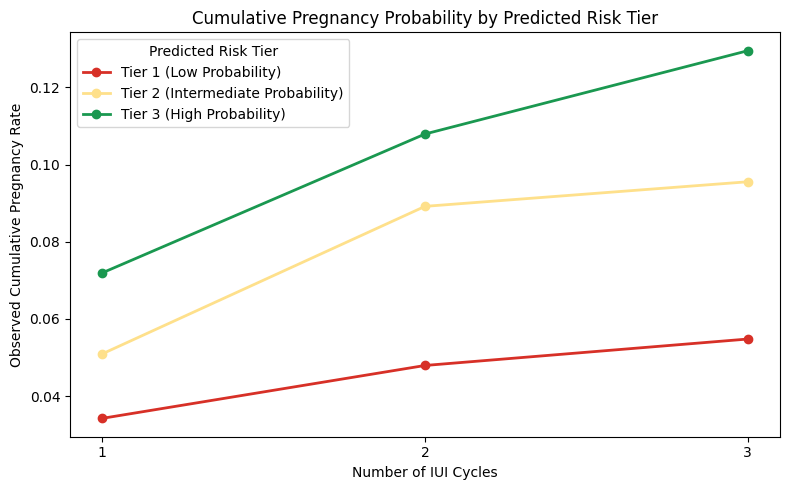

In [18]:
# ==========================================
# 9. CUMULATIVE PREGNANCY BY RISK TIER (1-3)
# ==========================================

import os

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/clinical', exist_ok=True)

if {'HN', 'Cycle_Number', 'Risk_Tier', 'Actual_Result'}.issubset(test_info.columns):

    tier_cum_df = test_info.copy()

    # ใช้เฉพาะ cycle 1-3
    tier_cum_df = tier_cum_df[tier_cum_df['Cycle_Number'] <= 3].copy()
    tier_cum_df = tier_cum_df.sort_values(['Risk_Tier', 'HN', 'Cycle_Number'])

    tier_order = [
        'Tier 1 (Low Probability)',
        'Tier 2 (Intermediate Probability)',
        'Tier 3 (High Probability)'
    ]

    cumulative_rows = []

    for tier in tier_order:
        sub_tier = tier_cum_df[tier_cum_df['Risk_Tier'] == tier].copy()

        if sub_tier.empty:
            continue

        patient_ids = sub_tier['HN'].dropna().unique()

        for k in [1, 2, 3]:
            sub_k = sub_tier[sub_tier['Cycle_Number'] <= k].copy()

            preg_by_k = (
                sub_k.groupby('HN')['Actual_Result']
                .max()
                .reindex(patient_ids, fill_value=0)
            )

            cumulative_rows.append({
                'Risk_Tier': tier,
                'Cycle': k,
                'Patients_in_Tier': len(patient_ids),
                'Observed_Cumulative_Pregnancy_Rate': preg_by_k.mean(),
                'Pregnancies_by_Cycle_k': preg_by_k.sum()
            })

    tier_cumulative_summary = pd.DataFrame(cumulative_rows)

    # save table
    tier_cumulative_summary.to_excel(
        'reports_ours/tables/Cumulative_Pregnancy_By_Risk_Tier.xlsx',
        index=False
    )

    print("\nCumulative Pregnancy by Risk Tier:")
    print(tier_cumulative_summary)

    # -------------------------
    # Plot cumulative tier curve
    # -------------------------

    plt.figure(figsize=(8, 5))

    tier_color_map = {
        'Tier 1 (Low Probability)': '#d73027',           # red
        'Tier 2 (Intermediate Probability)': '#fee08b',  # yellow
        'Tier 3 (High Probability)': '#1a9850'           # green
    }

    for tier in tier_order:
        sub = tier_cumulative_summary[tier_cumulative_summary['Risk_Tier'] == tier]
        if sub.empty:
            continue

        plt.plot(
            sub['Cycle'],
            sub['Observed_Cumulative_Pregnancy_Rate'],
            marker='o',
            linewidth=2,
            label=tier,
            color=tier_color_map[tier]
        )

    plt.xticks([1, 2, 3])
    plt.xlabel('Number of IUI Cycles')
    plt.ylabel('Observed Cumulative Pregnancy Rate')
    plt.title('Cumulative Pregnancy Probability by Predicted Risk Tier')
    plt.legend(title='Predicted Risk Tier')
    plt.tight_layout()

    plt.savefig(
        'reports_ours/figures/clinical/Cumulative_Pregnancy_By_Risk_Tier.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

else:
    print("ต้องมี HN, Cycle_Number, Risk_Tier และ Actual_Result ใน test_info")

### 7. Decision Curve Analysis (DCA)

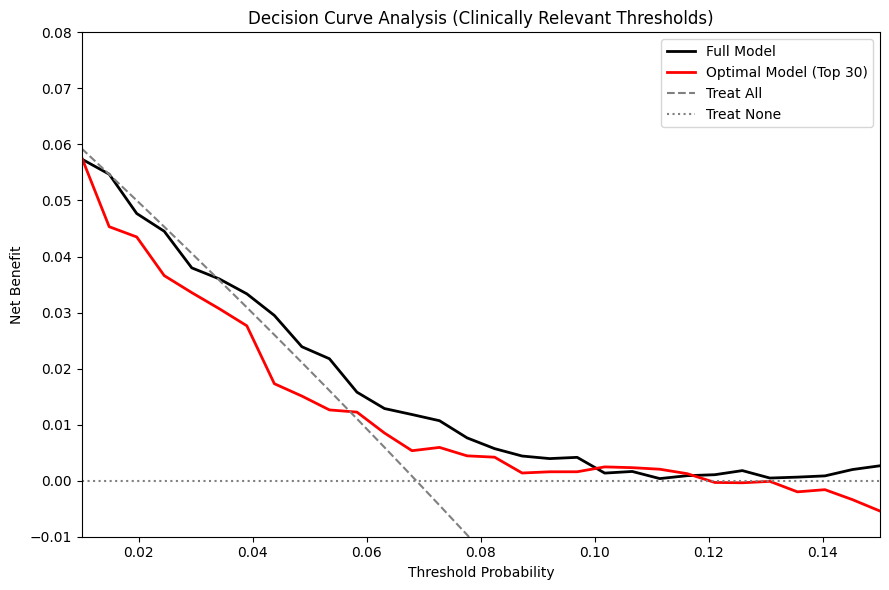


💡 Optimal model with 30 features shows comparable net benefit to the full model within clinically relevant thresholds (1–15%).


In [20]:
# =========================
# 10. Decision Curve Analysis (Clean Version)
# =========================

import os

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('reports_ours/figures/dca', exist_ok=True)

# clinically relevant threshold range
thresholds = np.linspace(0.01, 0.15, 30)

def build_model_from_best(best_key, best_model_obj):
    
    if 'MLP' in best_key:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(**best_model_obj.named_steps['model'].get_params()))
        ])

    p = best_model_obj.get_params().copy()
    for skip in ['verbose','logging_level','cat_features']:
        p.pop(skip, None)

    if 'CatBoost' in best_key:
        return CatBoostClassifier(**p, verbose=0)
    elif 'XGBoost' in best_key:
        return XGBClassifier(**p)
    elif 'RandomForest' in best_key:
        return RandomForestClassifier(**p)


def get_nb(k_features):

    sub_f = top_f[:k_features]

    m_dca = build_model_from_best(best_key, best_model_obj)

    m_dca.fit(X_train_res[sub_f], y_train_res)

    probs = m_dca.predict_proba(X_test[sub_f])[:,1]

    return [calculate_net_benefit(y_test, probs, t) for t in thresholds]


# full model
nb_full = [
    calculate_net_benefit(
        y_test,
        trained_models[best_key]['probs'],
        t
    )
    for t in thresholds
]

# optimal feature model
nb_opt = get_nb(optimal_k)

# treat all / treat none
nb_all = [
    calculate_net_benefit(
        y_test,
        np.ones(len(y_test)),
        t
    )
    for t in thresholds
]

nb_none = [0]*len(thresholds)

# save table
dca_df = pd.DataFrame({
    'Threshold':thresholds,
    'Net_Benefit_Full':nb_full,
    f'Net_Benefit_Top{optimal_k}':nb_opt,
    'Treat_All':nb_all,
    'Treat_None':nb_none
})

dca_df.to_excel(
    'reports_ours/tables/DCA_Analysis_Summary.xlsx',
    index=False
)

# plot
plt.figure(figsize=(9,6))

plt.plot(
    thresholds,
    nb_full,
    color='black',
    linewidth=2,
    label='Full Model'
)

plt.plot(
    thresholds,
    nb_opt,
    color='red',
    linewidth=2,
    label=f'Optimal Model (Top {optimal_k})'
)

plt.plot(
    thresholds,
    nb_all,
    color='gray',
    linestyle='--',
    label='Treat All'
)

plt.plot(
    thresholds,
    nb_none,
    color='gray',
    linestyle=':',
    label='Treat None'
)

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')

plt.title('Decision Curve Analysis (Clinically Relevant Thresholds)')

plt.xlim(0.01,0.15)
plt.ylim(-0.01,0.08)

plt.legend()

plt.tight_layout()

plt.savefig(
    'reports_ours/figures/dca/DCA_Comparison_Clean.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f"\n💡 Optimal model with {optimal_k} features shows comparable net benefit to the full model "
    f"within clinically relevant thresholds (1–15%)."
)

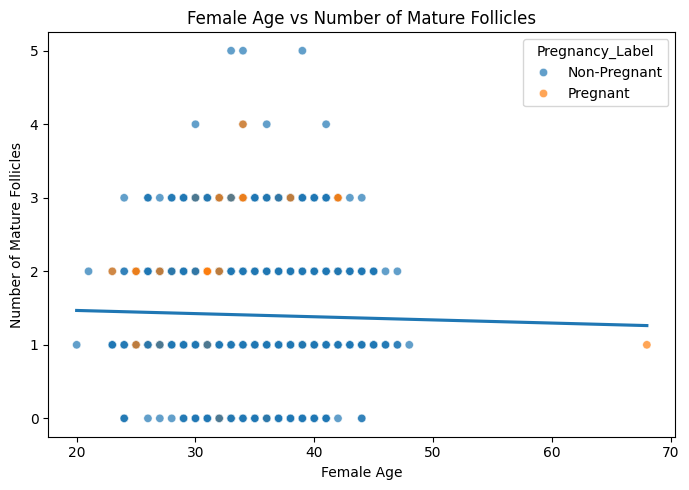

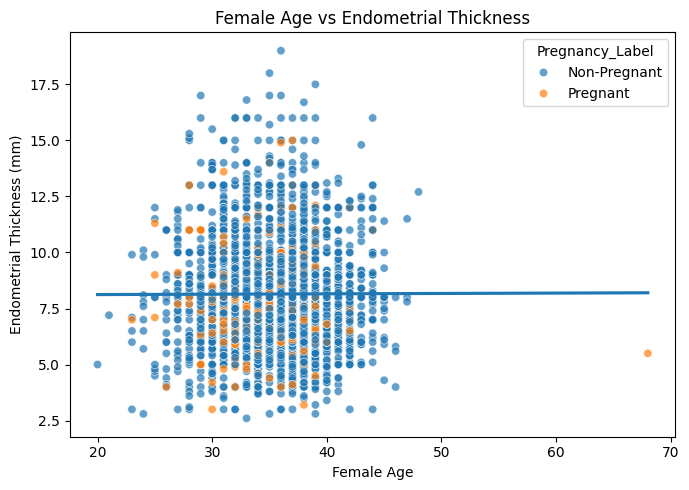

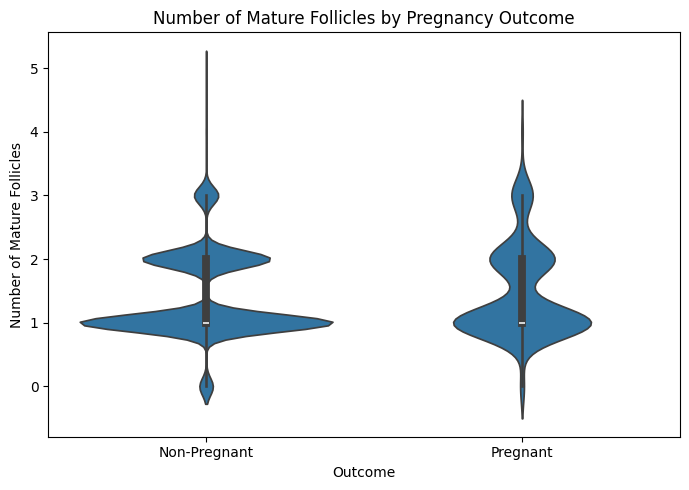

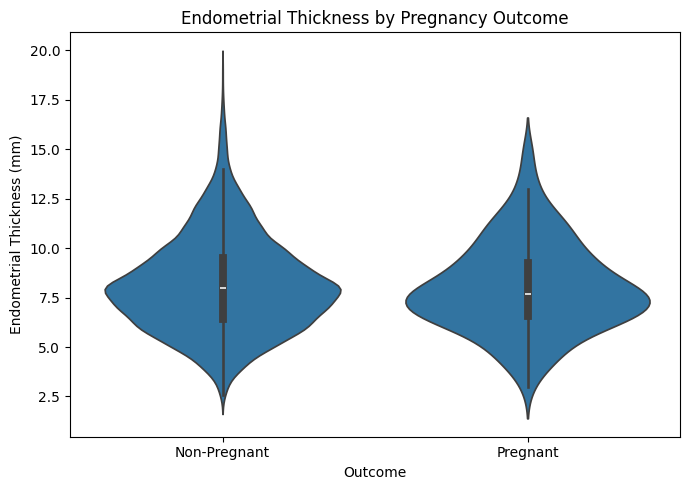

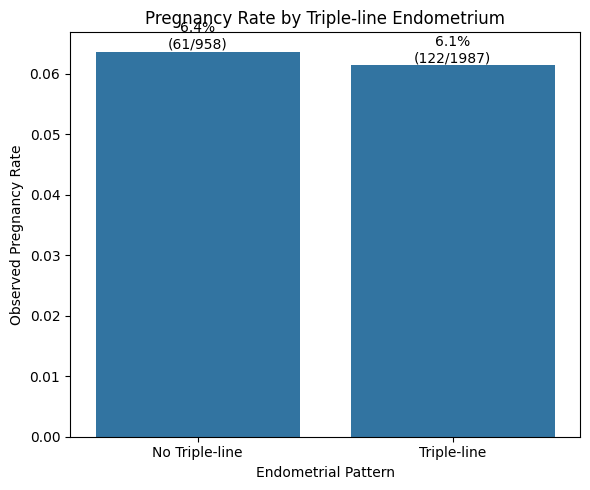

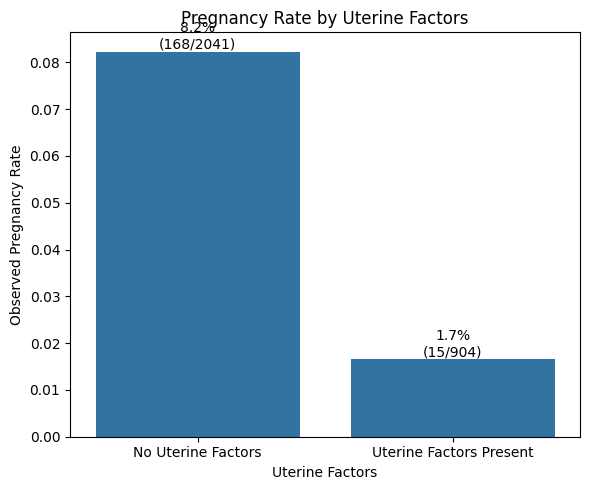

✅ Clinical relation plots saved to: reports_ours/figures/clinical_relations/


In [21]:
# ==========================================
# 11. Clinical Relation Plots for Bio Story
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_ours/figures/clinical_relations', exist_ok=True)

plot_df = df.copy()

# กันคอลัมน์ขยะจาก Excel ถ้ายังมี
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]

# ทำ outcome label ให้อ่านง่าย
plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

# -----------------------------
# 1) Female Age × Mature Follicles
# -----------------------------
if {'Age_Female', 'Mature_Follicle_Count', 'Result'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x='Age_Female',
        y='Mature_Follicle_Count',
        hue='Pregnancy_Label',
        alpha=0.7
    )
    sns.regplot(
        data=plot_df,
        x='Age_Female',
        y='Mature_Follicle_Count',
        scatter=False,
        ci=None
    )
    plt.title('Female Age vs Number of Mature Follicles')
    plt.xlabel('Female Age')
    plt.ylabel('Number of Mature Follicles')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/Age_vs_MatureFollicles.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 2) Female Age × Endometrial Thickness
# -----------------------------
if {'Age_Female', 'Endometrium_Thickness', 'Result'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x='Age_Female',
        y='Endometrium_Thickness',
        hue='Pregnancy_Label',
        alpha=0.7
    )
    sns.regplot(
        data=plot_df,
        x='Age_Female',
        y='Endometrium_Thickness',
        scatter=False,
        ci=None
    )
    plt.title('Female Age vs Endometrial Thickness')
    plt.xlabel('Female Age')
    plt.ylabel('Endometrial Thickness (mm)')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/Age_vs_EndometriumThickness.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 3) Mature Follicles × Pregnancy Outcome
# -----------------------------
if {'Mature_Follicle_Count', 'Pregnancy_Label'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.violinplot(
        data=plot_df,
        x='Pregnancy_Label',
        y='Mature_Follicle_Count',
        inner='box'
    )
    plt.title('Number of Mature Follicles by Pregnancy Outcome')
    plt.xlabel('Outcome')
    plt.ylabel('Number of Mature Follicles')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/MatureFollicles_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 4) Endometrial Thickness × Pregnancy Outcome
# -----------------------------
if {'Endometrium_Thickness', 'Pregnancy_Label'}.issubset(plot_df.columns):
    plt.figure(figsize=(7, 5))
    sns.violinplot(
        data=plot_df,
        x='Pregnancy_Label',
        y='Endometrium_Thickness',
        inner='box'
    )
    plt.title('Endometrial Thickness by Pregnancy Outcome')
    plt.xlabel('Outcome')
    plt.ylabel('Endometrial Thickness (mm)')
    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/EndometriumThickness_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 5) Triple-line Endometrium × Pregnancy Outcome
# -----------------------------
if {'Endo_Type_Triple', 'Result'}.issubset(plot_df.columns):
    triple_summary = (
        plot_df
        .groupby('Endo_Type_Triple')
        .agg(
            Total_Cycles=('Result', 'count'),
            Pregnancies=('Result', 'sum')
        )
        .reset_index()
    )
    triple_summary['Observed_Pregnancy_Rate'] = (
        triple_summary['Pregnancies'] / triple_summary['Total_Cycles']
    )
    triple_summary['Triple_Label'] = triple_summary['Endo_Type_Triple'].map({
        0: 'No Triple-line',
        1: 'Triple-line'
    })

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=triple_summary,
        x='Triple_Label',
        y='Observed_Pregnancy_Rate'
    )
    plt.title('Pregnancy Rate by Triple-line Endometrium')
    plt.xlabel('Endometrial Pattern')
    plt.ylabel('Observed Pregnancy Rate')

    for i, row in triple_summary.iterrows():
        plt.text(
            i,
            row['Observed_Pregnancy_Rate'],
            f"{row['Observed_Pregnancy_Rate']:.1%}\n({int(row['Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/TripleLineEndometrium_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

# -----------------------------
# 6) Uterine Factors × Pregnancy Outcome
# -----------------------------
if {'Uterine_Factors', 'Result'}.issubset(plot_df.columns):
    uterine_summary = (
        plot_df
        .groupby('Uterine_Factors')
        .agg(
            Total_Cycles=('Result', 'count'),
            Pregnancies=('Result', 'sum')
        )
        .reset_index()
    )
    uterine_summary['Observed_Pregnancy_Rate'] = (
        uterine_summary['Pregnancies'] / uterine_summary['Total_Cycles']
    )
    uterine_summary['Uterine_Label'] = uterine_summary['Uterine_Factors'].map({
        0: 'No Uterine Factors',
        1: 'Uterine Factors Present'
    })

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=uterine_summary,
        x='Uterine_Label',
        y='Observed_Pregnancy_Rate'
    )
    plt.title('Pregnancy Rate by Uterine Factors')
    plt.xlabel('Uterine Factors')
    plt.ylabel('Observed Pregnancy Rate')

    for i, row in uterine_summary.iterrows():
        plt.text(
            i,
            row['Observed_Pregnancy_Rate'],
            f"{row['Observed_Pregnancy_Rate']:.1%}\n({int(row['Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.savefig(
        'reports_ours/figures/clinical_relations/UterineFactors_by_PregnancyOutcome.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

print("✅ Clinical relation plots saved to: reports_ours/figures/clinical_relations/")